# Edge-Assisted Automated Inventory Tracking & Serial Label Verification
### Capstone Project · Review 2 · end-to-end prototype notebook
**Team:** Vishal Koushik · Gowthami Ambati · Ruth Caroline · Riyan Wankhede

**Problem.** Product labels and serial numbers are read and verified by hand. This is repetitive and slow, and error-prone
on small, unclear or reflective labels, especially under inconsistent lighting and camera angles.
**Objective.** Automate label/serial recognition, verify it against inventory data, and give an immediate
**PASS / MISMATCH** indication (plus **ERROR → re-capture** when nothing readable is found).

**Architecture (four layers, all running locally at the inspection station: edge-assisted):**

| Layer | Modules | Notebook section |
|---|---|---|
| **Input** | Camera → image acquisition | §2 (synthetic camera frames), §11 (real phone / webcam) |
| **Processing** | **YOLO detection → ROI extraction → preprocessing → OCR** | §3 detection, §4 ROI preprocessing, §5 OCR & normalisation |
| **Verification** | Text normalisation → inventory DB → match / mismatch decision | §1 database, §5 normalisation, §7 decision logic |
| **Output** | Microcontroller → green LED / red LED / buzzer | §8 hardware + firmware |

§6 integrates the modules, §9 runs the **12-step operating procedure** from the deck, and §10 is the **Testing &
Evaluation** plan from slide 12 (detection, OCR, verification, system testing), plus the ablation study and a second OCR engine.
§12 measures the **challenges and limitations** from slide 13 instead of just listing them.

**Our technical contribution** sits inside ROI preprocessing (§4): a *Geometric Pre-Processing & Attention-Crop layer*
(perspective correction, curvature dewarp, Radon skew, attention line crops, orientation check). The headline result is
**CER vs rotation angle 0–90°**: out-of-the-box OCR collapses, while the pipeline stays flat (§10.2).

**Safety net.** Every stage falls back to a simpler one (YOLO → classical locator → whole-frame Radon deskew → plain OCR),
so the station always returns a decision. The `RUN_*` flags in §0 skip the slow steps on re-runs; all results are cached.

## 0. Setup

In [1]:
# Run once if anything is missing (Tesseract itself: https://github.com/UB-Mannheim/tesseract/wiki on Windows)
# !pip install opencv-python pytesseract python-Levenshtein pillow matplotlib pandas qrcode pyzbar pyserial flask easyocr
# !pip install ultralytics          # YOLO detector (if it tries to replace your OpenCV build: pip install ultralytics --no-deps)

In [2]:
import os
os.environ.setdefault("OMP_THREAD_LIMIT", "1")   # one Tesseract thread per call; we parallelise over images

import math, random, re, shutil, string, sqlite3, time, json, threading
from dataclasses import dataclass, field, asdict
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import qrcode
import Levenshtein
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown

random.seed(7); np.random.seed(7)

# ---- run switches ---------------------------------------------------------------------
REGENERATE_DATASET = False   # True -> rebuild the synthetic images even if they exist
RERUN_EVALUATION   = False   # True -> recompute results even if cached CSVs exist
RUN_ABLATION       = True
RUN_EASYOCR        = True    # cross-engine check (downloads ~100 MB of models on first run)
TRAIN_YOLO         = True    # train the YOLO label detector if no trained weights exist yet
YOLO_EPOCHS        = 30      # ~45 s/epoch on a laptop CPU
WORKERS            = max(2, min(12, (os.cpu_count() or 4) - 2))

In [3]:
class config:
    # all paths are relative to this notebook's folder
    ROOT = Path.cwd()
    DATA_DIR = ROOT / "data"
    SYNTH_DIR = DATA_DIR / "synthetic"          # generated dataset: images/ + annotations.csv
    REAL_DIR = DATA_DIR / "real"                # YOUR phone/webcam photos: images/ + annotations.csv
    INCOMING_DIR = REAL_DIR / "incoming"        # photos uploaded from the phone web page
    INVENTORY_CSV = DATA_DIR / "inventory.csv"  # seed / your real stock list
    INVENTORY_DB = DATA_DIR / "inventory.db"    # SQLite DB used at runtime
    OUTPUT_DIR = ROOT / "outputs"
    FIG_DIR = OUTPUT_DIR / "figures"
    STAGE_DIR = OUTPUT_DIR / "stages"
    RESULT_DIR = OUTPUT_DIR / "results"
    HW_DIR = ROOT / "hardware"
    YOLO_DIR = DATA_DIR / "yolo"                # YOLO training set (separate from the test set)
    YOLO_WEIGHTS = OUTPUT_DIR / "yolo" / "label_detector" / "weights" / "best.pt"

    EXPECTED_ITEM = None     # station / order setting, e.g. "Motor Controller" -> other products = MISMATCH

    TESSERACT_CMD_CANDIDATES = [os.environ.get("TESSERACT_CMD", ""),
                                r"C:\Program Files\Tesseract-OCR\tesseract.exe",
                                r"C:\Program Files (x86)\Tesseract-OCR\tesseract.exe",
                                "/usr/bin/tesseract", "/opt/homebrew/bin/tesseract", "/usr/local/bin/tesseract"]
    SERIAL_ALPHABET = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-"
    SERIAL_REGEX = r"[A-Z0-9]{2,4}-[A-Z0-9]{3,7}-[A-Z0-9]{1,3}"   # loose structure of a serial

    MAX_SIDE = 1600          # phone photos are downscaled to this long side first
    MIN_OBJECT_FRAC = 0.02   # object must cover >= 2% of the frame
    LABEL_HEIGHT = 300       # rectified label height (px)

    MAX_EDIT_DISTANCE = 2    # OCR edits tolerated when matching the database
    MIN_MATCH_MARGIN = 1     # best match must beat the runner-up by this many edits

    SERIAL_PORT = os.environ.get("LV_SERIAL_PORT", "")   # "COM5", "/dev/ttyACM0"; empty = auto-detect / simulate
    SERIAL_BAUD = 9600

    FONT_CANDIDATES = {
        "mono": [r"C:\Windows\Fonts\consola.ttf", "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf"],
        "mono_bold": [r"C:\Windows\Fonts\consolab.ttf", r"C:\Windows\Fonts\courbd.ttf",
                      "/usr/share/fonts/truetype/dejavu/DejaVuSansMono-Bold.ttf"],
        "sans": [r"C:\Windows\Fonts\arial.ttf", "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"],
        "sans_bold": [r"C:\Windows\Fonts\arialbd.ttf", "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"],
        "ocr": [r"C:\Windows\Fonts\OCRAEXT.TTF", r"C:\Windows\Fonts\consola.ttf",
                "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf"],
        "narrow": [r"C:\Windows\Fonts\ARIALNB.TTF", r"C:\Windows\Fonts\bahnschrift.ttf",
                   r"C:\Windows\Fonts\arialbd.ttf", "/usr/share/fonts/truetype/dejavu/DejaVuSansCondensed-Bold.ttf"],
    }

for d in (config.SYNTH_DIR, config.REAL_DIR / "images", config.INCOMING_DIR, config.FIG_DIR,
          config.STAGE_DIR, config.RESULT_DIR, config.HW_DIR):
    d.mkdir(parents=True, exist_ok=True)
print("Project folder:", config.ROOT)

Project folder: E:\Wemby\label_verifier


In [4]:
# ---- figure style (validated colour-blind-safe palette; one colour per method, fixed everywhere) ----
C = {"baseline": "#eb6834", "rotation_only": "#1baf7a", "pipeline": "#2a78d6"}
LABEL = {"baseline": "Baseline OCR (raw frame)", "rotation_only": "Rotation-only deskew (prior prototype)",
         "pipeline": "Proposed geometric pipeline"}
INK, INK2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3dd", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "xtick.color": INK2, "ytick.color": INK2,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10.5,
    "axes.titlesize": 12, "axes.titleweight": "bold", "legend.frameon": False, "lines.linewidth": 2,
})

def show_photo_fig(fig, dpi=80, quality=82):
    # photo-heavy figures are displayed as JPEG so the notebook stays small enough for GitHub to render;
    # the files saved to outputs/figures/ are still full-quality PNGs
    import io
    from IPython.display import Image as IPImage
    buf = io.BytesIO()
    fig.savefig(buf, format="jpg", dpi=dpi, bbox_inches="tight", pil_kwargs={"quality": quality})
    plt.close(fig)
    display(IPImage(data=buf.getvalue()))

def show_images(imgs, titles=None, cols=4, size=3.6, cmap="gray", save=None):
    rows = math.ceil(len(imgs) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * size, rows * size * 0.78))
    for ax in np.atleast_1d(axes).ravel():
        ax.axis("off")
    for i, im in enumerate(imgs):
        ax = np.atleast_1d(axes).ravel()[i]
        ax.imshow(im, cmap=cmap if im.ndim == 2 else None)
        if titles:
            ax.set_title(titles[i], fontsize=9.5, fontweight="normal")
    plt.tight_layout()
    if save:
        plt.savefig(config.FIG_DIR / save, dpi=150, bbox_inches="tight")
    show_photo_fig(fig)

## 1. Inventory database (verification-layer data)

`data/inventory.csv` seeds a SQLite DB with an `items` table (serial, item, qty, location, status) and a
`scans` table that logs every verification event, which is the "inventory tracking" part of the system.
**To use your real stock list,** replace `data/inventory.csv` (same columns) and re-run this section.
`status = FAULTY` marks recalled or defective lots, so a correctly read serial still gives MISMATCH (red LED).
Every inspection is written to `scans`, so decisions are traceable for quality auditing (slide 8).

In [5]:
PREFIXES = ["SN", "PCB", "BOX", "CMP", "LBL", "MTR", "PSU", "CTL", "SEN", "DRV"]


ITEMS = {
    "SN": "Voltage Regulator Module", "PCB": "Main Controller PCB", "BOX": "Shipping Carton",
    "CMP": "Capacitor Bank Unit", "LBL": "Return Label Stock", "MTR": "BLDC Motor 24V",
    "PSU": "Power Supply 12V 5A", "CTL": "Motor Controller", "SEN": "Temperature Sensor Pack",
    "DRV": "Stepper Driver Board",
}


def random_serial(rng: random.Random) -> str:
    p = rng.choice(PREFIXES)
    mid_len = rng.choice([4, 5, 6])
    if rng.random() < 0.7:
        mid = "".join(rng.choices(string.digits, k=mid_len))
    else:
        mid = rng.choice(string.ascii_uppercase) + "".join(rng.choices(string.digits, k=mid_len - 1))
    suf = "".join(rng.choices(string.ascii_uppercase + string.digits, k=rng.choice([1, 2])))
    return f"{p}-{mid}-{suf}"


def make_inventory(n: int = 60, seed: int = 11, faulty_frac: float = 0.12) -> pd.DataFrame:
    """Seed inventory table. Replace data/inventory.csv with your real stock list later."""
    rng = random.Random(seed)
    serials: list[str] = []
    while len(serials) < n:
        s = random_serial(rng)
        if all(_lev(s, t) >= 4 for t in serials):
            serials.append(s)
    rows = []
    for s in serials:
        prefix = s.split("-")[0]
        status = "FAULTY" if rng.random() < faulty_frac else "OK"
        rows.append({
            "serial": s,
            "item": ITEMS[prefix],
            "qty": rng.randint(5, 500),
            "location": f"Rack-{rng.choice('ABCDE')}{rng.randint(1, 12):02d}",
            "status": status,
        })
    return pd.DataFrame(rows)


def _lev(a: str, b: str) -> int:
    import Levenshtein
    return Levenshtein.distance(a, b)

In [6]:
class InventoryDB:
    def __init__(self, db_path=config.INVENTORY_DB, seed_csv=config.INVENTORY_CSV):
        self.path = str(db_path)
        self.lock = threading.Lock()
        with self._conn() as c:
            c.execute("CREATE TABLE IF NOT EXISTS items (serial TEXT PRIMARY KEY, item TEXT, qty INTEGER, location TEXT, status TEXT)")
            c.execute('''CREATE TABLE IF NOT EXISTS scans (id INTEGER PRIMARY KEY AUTOINCREMENT, ts TEXT, source TEXT,
                         ocr_text TEXT, matched_serial TEXT, edit_distance INTEGER, decision TEXT, reason TEXT, conf REAL, qr TEXT, latency_ms INTEGER)''')
            cols = [r[1] for r in c.execute("PRAGMA table_info(scans)")]
            for col, typ in (("reason", "TEXT"), ("latency_ms", "INTEGER")):   # migrate DBs from older notebook versions
                if col not in cols:
                    c.execute(f"ALTER TABLE scans ADD COLUMN {col} {typ}")
            if c.execute("SELECT COUNT(*) FROM items").fetchone()[0] == 0 and Path(seed_csv).exists():
                pd.read_csv(seed_csv).to_sql("items", c, if_exists="append", index=False)
        self.refresh()

    def _conn(self):
        return sqlite3.connect(self.path, check_same_thread=False)

    def refresh(self):
        with self._conn() as c:
            self.items = pd.read_sql("SELECT * FROM items", c).set_index("serial")
        self.serials = list(self.items.index)

    def reseed(self, csv=config.INVENTORY_CSV):
        with self._conn() as c:
            c.execute("DELETE FROM items")
            pd.read_csv(csv).to_sql("items", c, if_exists="append", index=False)
        self.refresh()

    def match(self, text, max_edit=config.MAX_EDIT_DISTANCE, margin=config.MIN_MATCH_MARGIN):
        # Fuzzy match with an ambiguity guard: the best serial must be within max_edit edits AND
        # clearly better than the runner-up, otherwise we refuse to guess (-> red buzzer, re-scan).
        text = (text or "").strip().upper()
        if not text:
            return None, None
        d = sorted((Levenshtein.distance(text, s), s) for s in self.serials)
        best_d, best = d[0]
        second = d[1][0] if len(d) > 1 else 99
        if best_d <= max_edit and second - best_d >= margin:
            return best, best_d
        return None, best_d

    def log_scan(self, source, ocr_text, matched, dist, decision, reason, conf, qr="", latency_ms=0):
        with self.lock, self._conn() as c:
            c.execute("INSERT INTO scans (ts, source, ocr_text, matched_serial, edit_distance, decision, reason, conf, qr, latency_ms) "
                      "VALUES (datetime('now','localtime'),?,?,?,?,?,?,?,?,?)",
                      (source, ocr_text, matched, dist, decision, reason, conf, qr, latency_ms))

    def recent_scans(self, n=10):
        with self._conn() as c:
            return pd.read_sql(f"SELECT * FROM scans ORDER BY id DESC LIMIT {int(n)}", c)


if not config.INVENTORY_CSV.exists():
    make_inventory(n=60).to_csv(config.INVENTORY_CSV, index=False)
db = InventoryDB()
print(len(db.items), "items in inventory;", (db.items.status == "FAULTY").sum(), "flagged FAULTY")
db.items.head(8)

60 items in inventory; 4 flagged FAULTY


,item,qty,location,status
serial,,,,
CTL-Y45515-D,Motor Controller,264,Rack-E06,OK
LBL-8609-XW,Return Label Stock,317,Rack-E12,OK
BOX-501204-VH,Shipping Carton,329,Rack-C04,OK
CMP-006459-Z,Capacitor Bank Unit,132,Rack-E11,OK
MTR-0511-N8,BLDC Motor 24V,454,Rack-A11,OK
SN-9493-U,Voltage Regulator Module,143,Rack-C07,FAULTY
CMP-039712-A,Capacitor Bank Unit,24,Rack-A04,FAULTY
CTL-54171-EP,Motor Controller,42,Rack-A11,OK


## 2. Image acquisition: synthetic camera frames (input layer)

Each sample is a full 1280×960 webcam frame: one of **four label families** lying on a scan mat
(ESD mat, black, grey, wood or a green cutting mat with grid lines) under realistic nuisances:

* **Templates:** `component` (white QC sticker, black header), `shipping` (thermal label, OCR-A font, QR code),
  `pcb` (white silkscreen on green solder mask with traces and pads), `metal` (brushed, engraved nameplate with rivets and glare).
* **Geometry:** in-plane rotation, out-of-plane camera **tilt** (true pinhole homography), cylindrical **bending**,
  random-field **crumpling** with crease shading.
* **Photometry:** drop shadow, lighting gradient and vignette, specular glare, defocus blur, sensor noise, JPEG.

Every image goes to `data/synthetic/images/` and gets a row in `data/synthetic/annotations.csv` with the true serial,
every distortion parameter, the label's 4 true corners (ground truth for **detection testing**), and the expected
decision: `PASS`, or `MISMATCH` with a reason (`UNKNOWN_SERIAL` not in the DB, `FAULTY_LOT` flagged lot).
A real dataset only needs `filename, serial` (§11).

**Image-acquisition assumptions (slide 5):** the camera is fixed overhead, and the scan mat contrasts with the object.
The generator therefore never puts a green PCB on the green cutting mat or a grey metal plate on the grey mat.

**Splits.** `rotation` (0–90°, step 10°), `perspective` (tilt 0–50°), `curvature` (bend 0–25 % of label height),
`crumple` (0–15 px) each vary one factor with 12 images per level; `mixed` (160 images) randomises everything.

In [7]:
TEMPLATES = ("component", "shipping", "pcb", "metal")


CANVAS_W, CANVAS_H = 1280, 960  # webcam frame size used for synthetic captures


_font_cache: dict = {}


def font(kind: str, size: int) -> ImageFont.FreeTypeFont:
    key = (kind, size)
    if key not in _font_cache:
        for path in config.FONT_CANDIDATES.get(kind, []):
            if path and Path(path).exists():
                _font_cache[key] = ImageFont.truetype(path, size)
                break
        else:
            _font_cache[key] = ImageFont.load_default(size=size)
    return _font_cache[key]


def _center_text(draw, cx, cy, text, fnt, fill):
    b = draw.textbbox((0, 0), text, font=fnt)
    draw.text((cx - (b[2] - b[0]) / 2 - b[0], cy - (b[3] - b[1]) / 2 - b[1]), text, font=fnt, fill=fill)


def _fit_font(draw, text, kind, max_w, start):
    size = start
    while size > 12:
        f = font(kind, size)
        b = draw.textbbox((0, 0), text, font=f)
        if b[2] - b[0] <= max_w:
            return f
        size -= 2
    return font(kind, size)


def render_label(serial: str, template: str, item: str, rng: random.Random) -> np.ndarray:
    """Return an RGB uint8 image of a flat, frontal label."""
    if template == "component":
        W, H = 600, 270
        img = Image.new("RGB", (W, H), (246, 245, 238))
        d = ImageDraw.Draw(img)
        d.rectangle([6, 6, W - 7, H - 7], outline=(20, 20, 20), width=4)
        d.rectangle([6, 6, W - 7, 58], fill=(25, 25, 25))
        _center_text(d, W / 2, 32, "ACME ELECTRONICS  |  QC PASSED", font("sans_bold", 26), (245, 245, 245))
        f = _fit_font(d, serial, "mono_bold", W - 60, 70)
        _center_text(d, W / 2, 132, serial, f, (12, 12, 12))
        _center_text(d, W / 2, 196, f"PART: {item.upper()}", _fit_font(d, f"PART: {item.upper()}", "sans", W - 60, 24), (40, 40, 40))
        _center_text(d, W / 2, 232, f"LOT {rng.randint(10, 99)}{rng.choice('ABCDK')}   QTY {rng.randint(1, 50)}   MFG 2026",
                     font("sans", 22), (40, 40, 40))
    elif template == "shipping":
        W, H = 640, 300
        img = Image.new("RGB", (W, H), (250, 250, 244))
        d = ImageDraw.Draw(img)
        d.rectangle([5, 5, W - 6, H - 6], outline=(0, 0, 0), width=5)
        d.line([5, 70, W - 6, 70], fill=(0, 0, 0), width=4)
        d.text((20, 18), "SHIP TO: CENTRAL WAREHOUSE", font=font("sans_bold", 26), fill=(0, 0, 0))
        qr = qrcode.make(serial, border=1).convert("RGB").resize((180, 180), Image.NEAREST)
        img.paste(qr, (W - 200, 92))
        f = _fit_font(d, serial, "ocr", W - 250, 52)
        d.text((22, 110), serial, font=f, fill=(0, 0, 0))
        d.text((22, 190), f"WT {rng.randint(1, 30)}.{rng.randint(0, 9)} KG   PCS {rng.randint(1, 9)}/9",
               font=font("sans", 22), fill=(20, 20, 20))
        d.text((22, 230), "TRACKING VERIFIED", font=font("sans", 22), fill=(20, 20, 20))
        # thermal print banding
        arr = np.array(img).astype(np.int16)
        for y in range(0, H, rng.randint(9, 15)):
            arr[y] = np.clip(arr[y] + rng.randint(-8, 3), 0, 255)
        img = Image.fromarray(arr.astype(np.uint8))
    elif template == "pcb":
        W, H = 620, 290
        base = np.array([28, 92, 46]) + rng.randint(-8, 8)
        img = Image.new("RGB", (W, H), tuple(int(c) for c in base))
        d = ImageDraw.Draw(img)
        for _ in range(14):  # copper traces under solder mask
            y = rng.randint(10, H - 10)
            x0 = rng.randint(0, W // 2)
            d.line([x0, y, x0 + rng.randint(60, 300), y], fill=(40, 118, 60), width=3)
        for _ in range(10):  # gold pads / vias
            x, y = rng.randint(15, W - 15), rng.choice([rng.randint(12, 40), rng.randint(H - 40, H - 12)])
            d.ellipse([x - 6, y - 6, x + 6, y + 6], fill=(205, 170, 70))
        d.rectangle([4, 4, W - 5, H - 5], outline=(210, 220, 210), width=3)
        f = _fit_font(d, serial, "mono_bold", W - 90, 66)
        _center_text(d, W / 2, 128, serial, f, (240, 242, 236))
        _center_text(d, W / 2, 200, f"REV {rng.choice('ABCD')}{rng.randint(1, 9)}  {item.upper()}",
                     _fit_font(d, f"REV A1  {item.upper()}", "sans_bold", W - 80, 24), (232, 235, 228))
    elif template == "metal":
        W, H = 600, 270
        x = np.linspace(0, 1, W)[None, :, None]
        y = np.linspace(0, 1, H)[:, None, None]
        grad = 150 + 50 * np.sin(2.4 * x + 1.1 * y + rng.random())
        streaks = cv2.GaussianBlur(np.random.default_rng(rng.randint(0, 1 << 30)).normal(0, 14, (H, W)), (0, 0), sigmaX=40, sigmaY=0.6)
        arr = np.clip(grad + streaks[..., None] + np.array([2, 4, 8]), 0, 255).astype(np.uint8)
        img = Image.fromarray(arr)
        d = ImageDraw.Draw(img)
        for cx, cy in [(22, 22), (W - 22, 22), (22, H - 22), (W - 22, H - 22)]:
            d.ellipse([cx - 9, cy - 9, cx + 9, cy + 9], fill=(110, 112, 118), outline=(70, 70, 75), width=2)
        f = _fit_font(d, serial, "narrow", W - 100, 74)
        _center_text(d, W / 2 + 1, 122, serial, f, (235, 235, 240))  # engraving highlight
        _center_text(d, W / 2, 120, serial, f, (35, 35, 40))
        _center_text(d, W / 2, 200, f"MODEL {item.upper()}", _fit_font(d, f"MODEL {item.upper()}", "sans_bold", W - 90, 24), (45, 45, 50))
    else:
        raise ValueError(template)
    return np.array(img)

In [8]:
def bend(rgba: np.ndarray, amount: float, label_h: int) -> np.ndarray:
    """Cylindrical bow: label centre pushed by amount*label_h, edges fixed (curved product surface)."""
    if amount == 0:
        return rgba
    H, W = rgba.shape[:2]
    xs = np.arange(W, dtype=np.float32)
    u = (xs - W / 2) / (W / 2)
    dy = amount * label_h * (1 - u ** 2)
    map_x = np.tile(xs, (H, 1))
    map_y = np.arange(H, dtype=np.float32)[:, None] - dy[None, :]
    out = cv2.remap(rgba, map_x, map_y.astype(np.float32), cv2.INTER_LINEAR, borderValue=(0, 0, 0, 0))
    # shading across the cylinder
    shade = (0.82 + 0.18 * np.cos(u * math.pi / 2 * min(1, amount * 4)))[None, :, None]
    out[..., :3] = np.clip(out[..., :3] * shade, 0, 255)
    return out


def crumple(rgba: np.ndarray, amount: float, rng: np.random.Generator) -> np.ndarray:
    """Smooth random displacement + crease shading (crumpled paper / folded thermal label)."""
    if amount == 0:
        return rgba
    H, W = rgba.shape[:2]
    def field(sigma):
        f = cv2.GaussianBlur(rng.normal(0, 1, (H, W)).astype(np.float32), (0, 0), sigma)
        return f / (np.abs(f).max() + 1e-6)
    dx = field(45) * amount
    dy = field(45) * amount
    map_x = (np.arange(W, dtype=np.float32)[None, :] + dx).astype(np.float32)
    map_y = (np.arange(H, dtype=np.float32)[:, None] + dy).astype(np.float32)
    out = cv2.remap(rgba, map_x, map_y, cv2.INTER_LINEAR, borderValue=(0, 0, 0, 0))
    gy, gx = np.gradient(dy + dx)
    shade = 1 + 2.2 * (gx + gy)
    # a few sharp creases
    crease = np.zeros((H, W), np.float32)
    for _ in range(int(1 + amount // 4)):
        p1 = (int(rng.uniform(0, W)), 0); p2 = (int(rng.uniform(0, W)), H)
        cv2.line(crease, p1, p2, 1.0, 2)
    crease = cv2.GaussianBlur(crease, (0, 0), 1.5)
    shade = shade - 0.25 * crease
    out[..., :3] = np.clip(out[..., :3] * shade[..., None], 0, 255)
    return out


def tilt_homography(w: float, h: float, tilt_deg: float, axis_deg: float, f: float = 1400.0) -> np.ndarray:
    """Homography that maps a w*h frontal rectangle (centred at 0) to its pinhole projection
    after rotating it out of plane by tilt_deg around an in-plane axis at axis_deg."""
    t, a = math.radians(tilt_deg), math.radians(axis_deg)
    ax = np.array([math.cos(a), math.sin(a), 0.0])
    K = np.array([[0, -ax[2], ax[1]], [ax[2], 0, -ax[0]], [-ax[1], ax[0], 0]])
    R = np.eye(3) + math.sin(t) * K + (1 - math.cos(t)) * K @ K
    src = np.array([[-w / 2, -h / 2], [w / 2, -h / 2], [w / 2, h / 2], [-w / 2, h / 2]], np.float32)
    dst = []
    for x, y in src:
        X, Y, Z = R @ np.array([x, y, 0.0])
        dst.append([f * X / (Z + f), f * Y / (Z + f)])
    return np.array(dst, np.float32)

In [9]:
def make_background(rng: np.random.Generator, template: str = "") -> np.ndarray:
    # assumption of the rig: the scan mat contrasts with the object
    # (no green PCB on the green cutting mat, no grey metal plate on the grey mat)
    kinds = ["esd", "black", "wood"] + ([] if template == "metal" else ["grey"]) + ([] if template == "pcb" else ["cutmat"])
    kind = rng.choice(kinds)
    base = {"esd": (58, 66, 78), "black": (34, 34, 38), "grey": (92, 94, 98),
            "wood": (118, 84, 56), "cutmat": (36, 84, 66)}[kind]
    bg = np.ones((CANVAS_H, CANVAS_W, 3), np.float32) * np.array(base, np.float32)
    low = cv2.resize(rng.normal(0, 1, (6, 8)).astype(np.float32), (CANVAS_W, CANVAS_H), interpolation=cv2.INTER_CUBIC)
    bg += low[..., None] * 10
    if kind == "wood":
        grain = cv2.GaussianBlur(rng.normal(0, 1, (CANVAS_H, CANVAS_W)).astype(np.float32), (0, 0), sigmaX=60, sigmaY=1.5)
        bg += grain[..., None] * 160
    else:
        bg += rng.normal(0, 4, bg.shape)
    if kind == "cutmat":
        for x in range(0, CANVAS_W, 64):
            bg[:, x:x + 2] += 45
        for y in range(0, CANVAS_H, 64):
            bg[y:y + 2, :] += 45
    return np.clip(bg, 0, 255)


@dataclass
class SampleSpec:
    serial: str
    template: str
    item: str = ""
    angle: float = 0.0        # in-plane rotation (deg)
    tilt: float = 0.0         # out-of-plane camera tilt (deg)
    tilt_axis: float = 0.0
    bend: float = 0.0         # cylindrical bow as fraction of label height
    crumple: float = 0.0      # crumple displacement amplitude (px)
    blur: float = 0.0         # gaussian defocus sigma (px)
    noise: float = 4.0        # sensor noise std
    glare: float = 0.0        # glare blob intensity 0..1
    light: float = 0.15       # illumination gradient strength
    scale: float = 1.0
    jpeg: int = 92
    seed: int = 0
    corners: list = field(default_factory=list)  # filled after rendering: label quad in frame


def render_scene(spec: SampleSpec) -> np.ndarray:
    rng = random.Random(spec.seed)
    nrng = np.random.default_rng(spec.seed)
    label = render_label(spec.serial, spec.template, spec.item, rng)
    h, w = label.shape[:2]
    pad = int(0.45 * h)
    rgba = np.zeros((h + 2 * pad, w + 2 * pad, 4), np.float32)
    rgba[pad:pad + h, pad:pad + w, :3] = label
    rgba[pad:pad + h, pad:pad + w, 3] = 255
    rgba = bend(rgba, spec.bend, h)
    rgba = crumple(rgba, spec.crumple, nrng)

    # Homography: padded label canvas -> frame. Built from the label rectangle's 4 corners.
    proj = tilt_homography(w * spec.scale, h * spec.scale, spec.tilt, spec.tilt_axis)
    th = math.radians(spec.angle)
    Rz = np.array([[math.cos(th), math.sin(th)], [-math.sin(th), math.cos(th)]], np.float32)  # CCW on screen
    proj = proj @ Rz.T
    max_off_x = CANVAS_W / 2 - np.abs(proj[:, 0]).max() - 30
    max_off_y = CANVAS_H / 2 - np.abs(proj[:, 1]).max() - 30
    cx = CANVAS_W / 2 + rng.uniform(-1, 1) * max(0, max_off_x) * 0.6
    cy = CANVAS_H / 2 + rng.uniform(-1, 1) * max(0, max_off_y) * 0.6
    dst = proj + np.array([cx, cy], np.float32)
    src = np.array([[pad, pad], [pad + w, pad], [pad + w, pad + h], [pad, pad + h]], np.float32)
    Hm = cv2.getPerspectiveTransform(src, dst)
    warped = cv2.warpPerspective(rgba, Hm, (CANVAS_W, CANVAS_H), flags=cv2.INTER_LINEAR, borderValue=(0, 0, 0, 0))
    spec.corners = dst.round(1).tolist()

    bg = make_background(nrng, spec.template)
    alpha = warped[..., 3:4] / 255.0
    # drop shadow
    sh = cv2.GaussianBlur(alpha[..., 0], (0, 0), 9)
    sh = np.roll(sh, (10, 12), axis=(0, 1))
    bg *= (1 - 0.45 * sh[..., None])
    frame = bg * (1 - alpha) + warped[..., :3] * alpha

    # lighting gradient + vignette
    yy, xx = np.mgrid[0:CANVAS_H, 0:CANVAS_W].astype(np.float32)
    ga = rng.uniform(0, 2 * math.pi)
    gradient = 1 + spec.light * ((xx / CANVAS_W - 0.5) * math.cos(ga) + (yy / CANVAS_H - 0.5) * math.sin(ga)) * 2
    vign = 1 - 0.18 * (((xx - CANVAS_W / 2) / CANVAS_W) ** 2 + ((yy - CANVAS_H / 2) / CANVAS_H) ** 2) * 2
    frame *= (gradient * vign)[..., None]
    if spec.glare > 0:
        gx, gy = rng.uniform(0.25, 0.75) * CANVAS_W, rng.uniform(0.25, 0.75) * CANVAS_H
        r = rng.uniform(60, 140)
        blob = np.exp(-(((xx - gx) ** 2 + (yy - gy) ** 2) / (2 * r ** 2)))
        frame += spec.glare * 120 * blob[..., None]
    if spec.blur > 0:
        frame = cv2.GaussianBlur(frame, (0, 0), spec.blur)
    frame += nrng.normal(0, spec.noise, frame.shape)
    frame = np.clip(frame, 0, 255).astype(np.uint8)
    ok, enc = cv2.imencode(".jpg", cv2.cvtColor(frame, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, spec.jpeg])
    return cv2.cvtColor(cv2.imdecode(enc, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

In [10]:
def _nuisance(rng: random.Random, template: str, strength: float = 1.0) -> dict:
    return dict(
        noise=rng.uniform(2, 7) * strength,
        blur=rng.choice([0, 0, 0.6, 1.0]) * strength,
        light=rng.uniform(0.05, 0.25),
        glare=(rng.uniform(0.3, 0.8) if template == "metal" else rng.uniform(0, 0.3)) * strength,
        jpeg=rng.randint(75, 95),
        scale=rng.uniform(0.85, 1.15),
        tilt_axis=rng.uniform(0, 180),
    )


def build_specs(inventory: pd.DataFrame, per_level: int = 12, n_mixed: int = 160,
                unknown_frac: float = 0.25, seed: int = 2026) -> list[tuple[str, dict, SampleSpec]]:
    rng = random.Random(seed)
    db = inventory.to_dict("records")
    known = [r["serial"] for r in db]
    item_of = {r["serial"]: r["item"] for r in db}
    status_of = {r["serial"]: r["status"] for r in db}

    def pick_serial():
        if rng.random() < unknown_frac:
            while True:
                s = random_serial(rng)
                if all(_lev(s, k) >= 4 for k in known):
                    return s, "FAIL_UNKNOWN"
        s = rng.choice(known)
        return s, ("FAIL_FAULTY" if status_of[s] == "FAULTY" else "PASS")

    sweeps = {
        "rotation":    ("angle",   list(range(0, 91, 10))),
        "perspective": ("tilt",    [0, 10, 20, 30, 40, 50]),
        "curvature":   ("bend",    [0.0, 0.05, 0.1, 0.15, 0.2, 0.25]),
        "crumple":     ("crumple", [0, 3, 6, 9, 12, 15]),
    }
    specs = []
    idx = 0
    for split, (param, levels) in sweeps.items():
        for level in levels:
            for k in range(per_level):
                serial, expected = pick_serial()
                template = TEMPLATES[idx % len(TEMPLATES)]
                kw = _nuisance(rng, template, 0.6)
                # the sweeps vary ONE factor; rotation is randomised in the other sweeps so
                # every split still contains skewed placements
                kw["angle"] = rng.uniform(0, 90) if split != "rotation" else float(level)
                kw[param] = float(level)
                spec = SampleSpec(serial=serial, template=template, item=item_of.get(serial, "Unregistered Part"),
                                  seed=rng.randint(0, 1 << 30), **kw)
                specs.append((split, {"level": level, "expected": expected}, spec))
                idx += 1
    for k in range(n_mixed):
        serial, expected = pick_serial()
        template = rng.choice(TEMPLATES)
        kw = _nuisance(rng, template, 1.0)
        kw.update(angle=rng.uniform(0, 90), tilt=rng.uniform(0, 35), bend=rng.choice([0, 0, 0.05, 0.12]),
                  crumple=rng.choice([0, 0, 3, 7]))
        spec = SampleSpec(serial=serial, template=template, item=item_of.get(serial, "Unregistered Part"),
                          seed=rng.randint(0, 1 << 30), **kw)
        specs.append(("mixed", {"level": None, "expected": expected}, spec))
    return specs


def generate_dataset(out_dir: Path = config.SYNTH_DIR, per_level: int = 12, n_mixed: int = 160,
                     inventory_csv: Path = config.INVENTORY_CSV, workers: int = WORKERS, verbose: bool = True) -> pd.DataFrame:
    out_dir = Path(out_dir)
    (out_dir / "images").mkdir(parents=True, exist_ok=True)
    if not Path(inventory_csv).exists():
        make_inventory().to_csv(inventory_csv, index=False)
    inventory = pd.read_csv(inventory_csv)
    specs = build_specs(inventory, per_level=per_level, n_mixed=n_mixed)

    def job(i_item):
        i, (split, meta, spec) = i_item
        fname = f"{split}_{i:04d}.jpg"
        img = render_scene(spec)
        cv2.imwrite(str(out_dir / "images" / fname), cv2.cvtColor(img, cv2.COLOR_RGB2BGR), [cv2.IMWRITE_JPEG_QUALITY, 95])
        reason = {"PASS": "OK", "FAIL_UNKNOWN": "UNKNOWN_SERIAL", "FAIL_FAULTY": "FAULTY_LOT"}[meta["expected"]]
        row = {"filename": f"images/{fname}", "split": split, "level": meta["level"],
               "expected_decision": "PASS" if reason == "OK" else "MISMATCH", "expected_reason": reason,
               **asdict(spec)}
        row["corners"] = ";".join(f"{x:.1f},{y:.1f}" for x, y in spec.corners)
        return row

    with ThreadPoolExecutor(workers) as ex:
        rows = list(ex.map(job, enumerate(specs)))
    df = pd.DataFrame(rows)
    df.to_csv(out_dir / "annotations.csv", index=False)
    if verbose:
        print(f"Wrote {len(df)} images to {out_dir}")
        print(df.groupby("split").size().to_string())
    return df

In [11]:
ann_path = config.SYNTH_DIR / "annotations.csv"
if REGENERATE_DATASET or not ann_path.exists():
    t0 = time.time()
    ann = generate_dataset()
    print(f"generated in {time.time() - t0:.0f}s")
else:
    ann = pd.read_csv(ann_path)
    print(f"Loaded existing dataset: {len(ann)} images  (set REGENERATE_DATASET=True to rebuild)")
# datasets generated by an older version used FAIL_UNKNOWN / FAIL_FAULTY -> map to the Review-2 decision states
if "expected_reason" not in ann:
    ann["expected_reason"] = ann.expected_decision.map({"PASS": "OK", "FAIL_UNKNOWN": "UNKNOWN_SERIAL", "FAIL_FAULTY": "FAULTY_LOT"})
    ann["expected_decision"] = np.where(ann.expected_reason == "OK", "PASS", "MISMATCH")
display(ann.groupby(["split"]).size().rename("images").to_frame().T)
display(pd.crosstab(ann.expected_decision, ann.expected_reason))
ann[["filename", "split", "serial", "template", "angle", "tilt", "bend", "crumple", "expected_decision", "expected_reason"]].head()

Loaded existing dataset: 496 images  (set REGENERATE_DATASET=True to rebuild)


split,crumple,curvature,mixed,perspective,rotation
images,72,72,160,72,120


expected_reason,FAULTY_LOT,OK,UNKNOWN_SERIAL
expected_decision,,,
MISMATCH,17,0,124
PASS,0,355,0


,filename,split,serial,template,angle,tilt,bend,crumple,expected_decision,expected_reason
0,images/rotation_0000.jpg,rotation,SEN-988645-1V,component,0.0,0.0,0.0,0.0,MISMATCH,UNKNOWN_SERIAL
1,images/rotation_0001.jpg,rotation,PCB-5862-0,shipping,0.0,0.0,0.0,0.0,PASS,OK
2,images/rotation_0002.jpg,rotation,SN-9493-U,pcb,0.0,0.0,0.0,0.0,MISMATCH,FAULTY_LOT
3,images/rotation_0003.jpg,rotation,LBL-4983-YZ,metal,0.0,0.0,0.0,0.0,PASS,OK
4,images/rotation_0004.jpg,rotation,PCB-5851-LN,component,0.0,0.0,0.0,0.0,PASS,OK


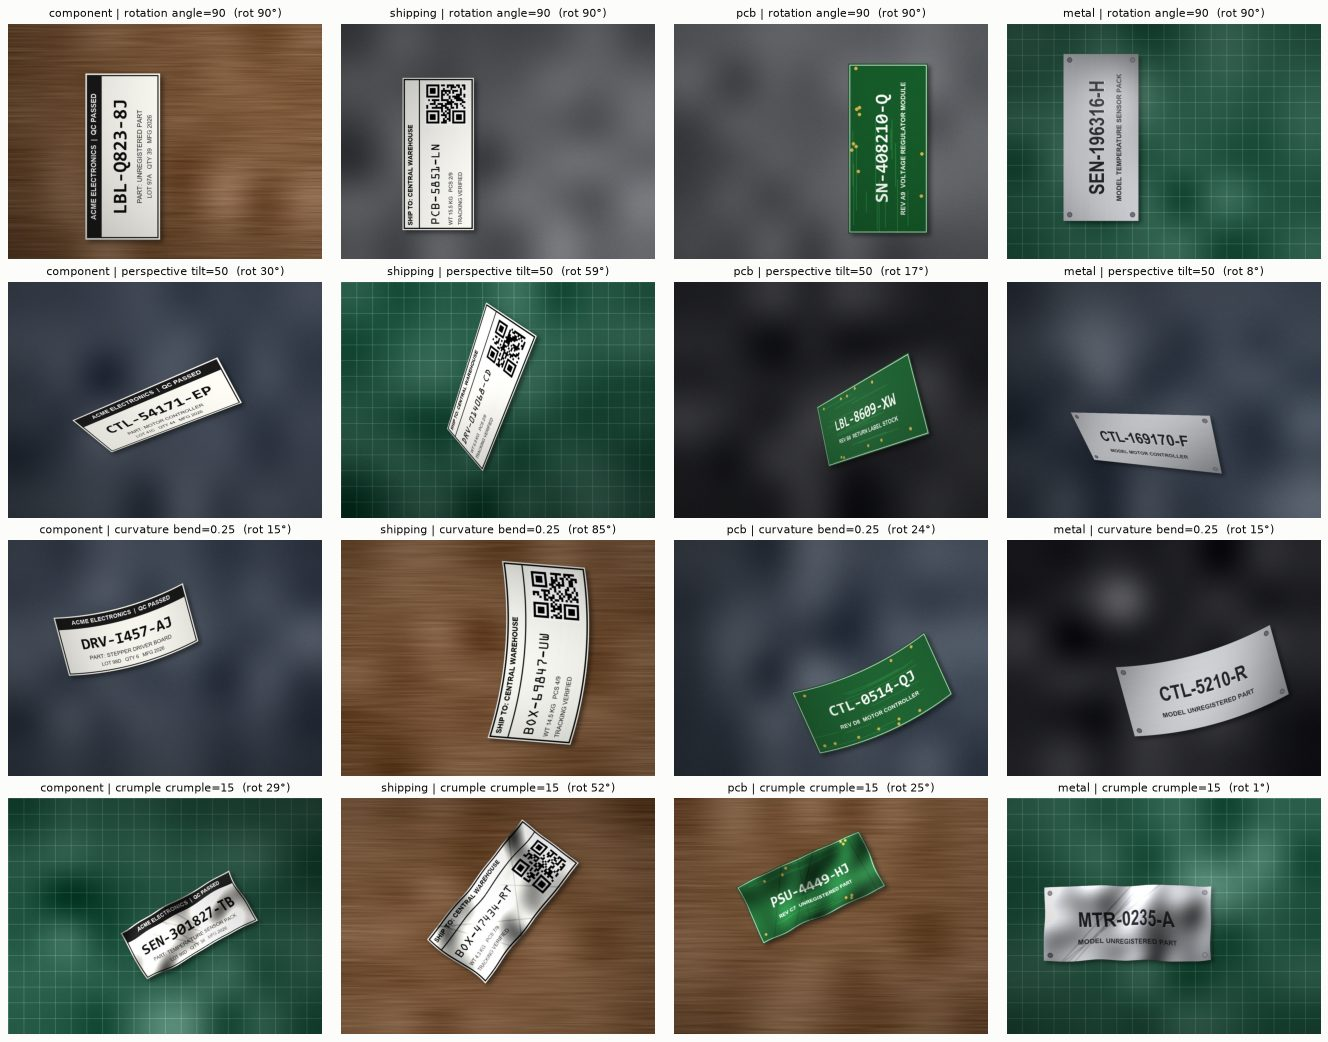

In [12]:
def load_rgb(path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# one sample per (template x distortion family)
picks, titles = [], []
for split, col in [("rotation", "angle"), ("perspective", "tilt"), ("curvature", "bend"), ("crumple", "crumple")]:
    sub = ann[ann.split == split]
    for t in TEMPLATES:
        r = sub[(sub.template == t)].sort_values("level").iloc[-1]
        picks.append(load_rgb(config.SYNTH_DIR / r.filename))
        titles.append(f"{t} | {split} {col}={r[col]:.2g}  (rot {r.angle:.0f}°)")
show_images(picks, titles, cols=4, size=4.2, save="dataset_samples.png")

## 3. Object / label detection: YOLO → ROI extraction (processing layer)

Slide 5: *a YOLO-based detector identifies the target region, its bounding box is used to crop the ROI, and the ROI
removes unnecessary information before OCR.*

* **Training data without manual labelling.** The generator knows every label's exact corners, so YOLO boxes come for
  free. The detector is trained on a **separate** set of 500 synthetic frames (new random seeds, full 0–360° rotation,
  tilt, bending, crumpling, and 5 % empty-mat frames). It is tested on the §2 evaluation set, which it never saw.
* **Model:** YOLO11n (2.6 M parameters, ~20 ms per frame on CPU), so it fits the edge-station budget.
* **ROI extraction** keeps a 12 % margin of mat around the box, because the next stage (§4) models the background from the ROI border.
* **Fallback:** if YOLO isn't installed, isn't trained, or finds nothing, the classical border-model locator from §4
  takes over (`LabelDetector.name` says which is active).

In [13]:
def corners_to_bbox(corners) -> tuple[float, float, float, float]:
    pts = np.asarray(corners, np.float32).reshape(-1, 2)
    x0, y0 = np.clip(pts.min(0), 0, [CANVAS_W - 1, CANVAS_H - 1])
    x1, y1 = np.clip(pts.max(0), 0, [CANVAS_W - 1, CANVAS_H - 1])
    return float(x0), float(y0), float(x1), float(y1)


def parse_corners(s: str):
    return [tuple(map(float, p.split(","))) for p in s.split(";")]


def bbox_iou(a, b) -> float:
    ix0, iy0, ix1, iy1 = max(a[0], b[0]), max(a[1], b[1]), min(a[2], b[2]), min(a[3], b[3])
    inter = max(0.0, ix1 - ix0) * max(0.0, iy1 - iy0)
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


def make_yolo_dataset(out_dir: Path = config.DATA_DIR / "yolo", n_train: int = 400, n_val: int = 100,
                      empty_frac: float = 0.05, seed: int = 777, workers: int = 8) -> Path:
    """Write a YOLO-format detection dataset (images/, labels/, data.yaml) from fresh synthetic
    scenes with the full range of rotation (0-360), tilt, bending, crumpling and lighting."""
    out_dir = Path(out_dir)
    rng = random.Random(seed)
    jobs = []
    for split, n in (("train", n_train), ("val", n_val)):
        (out_dir / "images" / split).mkdir(parents=True, exist_ok=True)
        (out_dir / "labels" / split).mkdir(parents=True, exist_ok=True)
        for i in range(n):
            template = rng.choice(TEMPLATES)
            kw = _nuisance(rng, template, rng.uniform(0.5, 1.2))
            kw.update(angle=rng.uniform(0, 360), tilt=rng.uniform(0, 45), bend=rng.choice([0, 0, 0.08, 0.18]),
                      crumple=rng.choice([0, 0, 4, 10]))
            spec = SampleSpec(serial=random_serial(rng), template=template, item="", seed=rng.randint(0, 1 << 30), **kw)
            jobs.append((split, i, spec, rng.random() < empty_frac))

    def job(j):
        split, i, spec, empty = j
        img = render_scene(spec)
        if empty:  # empty scan area: teaches the detector "nothing placed"
            img = np.clip(make_background(np.random.default_rng(spec.seed)), 0, 255).astype(np.uint8)
        name = f"{split}_{i:04d}"
        cv2.imwrite(str(out_dir / "images" / split / f"{name}.jpg"), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        with open(out_dir / "labels" / split / f"{name}.txt", "w") as fh:
            if not empty:
                x0, y0, x1, y1 = corners_to_bbox(spec.corners)
                fh.write(f"0 {(x0 + x1) / 2 / CANVAS_W:.6f} {(y0 + y1) / 2 / CANVAS_H:.6f} "
                         f"{(x1 - x0) / CANVAS_W:.6f} {(y1 - y0) / CANVAS_H:.6f}\n")

    with ThreadPoolExecutor(workers) as ex:
        list(ex.map(job, jobs))
    yaml = out_dir / "data.yaml"
    yaml.write_text(f"path: {out_dir.as_posix()}\ntrain: images/train\nval: images/val\nnames:\n  0: label\n")
    return yaml


def train_yolo(data_yaml: Path, epochs: int = 25, imgsz: int = 512, model: str = "yolo11n.pt",
               project: Path = config.OUTPUT_DIR / "yolo", name: str = "label_detector") -> Path:
    from ultralytics import YOLO
    m = YOLO(model)
    m.train(data=str(data_yaml), epochs=epochs, imgsz=imgsz, batch=16, device="cpu", workers=4,
            project=str(project), name=name, exist_ok=True, plots=True, verbose=False,
            degrees=0, fliplr=0.5, flipud=0.5, mosaic=0.5, patience=50, seed=0)
    return Path(project) / name / "weights" / "best.pt"

In [14]:
class LabelDetector:
    """YOLO first; if YOLO is unavailable or finds nothing, fall back to the classical
    border-model segmentation, so the station never stops working."""

    def __init__(self, weights: Path | None = None, conf: float = 0.25, imgsz: int = 512):
        import threading
        self.model, self.conf, self.imgsz = None, conf, imgsz
        self.lock = threading.Lock()   # ultralytics models are not thread-safe
        if weights and Path(weights).exists():
            from ultralytics import YOLO
            self.model = YOLO(str(weights))
        self.name = "yolo" if self.model is not None else "classical"

    def detect(self, img: np.ndarray):
        """Return (bbox x0,y0,x1,y1, confidence, source) or (None, 0, source)."""
        if self.model is not None:
            with self.lock:
                r = self.model.predict(img, imgsz=self.imgsz, conf=self.conf, device="cpu", verbose=False)[0]
            if len(r.boxes):
                i = int(r.boxes.conf.argmax())
                return tuple(float(v) for v in r.boxes.xyxy[i].tolist()), float(r.boxes.conf[i]), "yolo"
        g = locate(img)
        if g.found:
            x, y, w, h = cv2.boundingRect(g.quad.astype(np.int32))
            return (float(x), float(y), float(x + w), float(y + h)), g.rectangularity, "classical"
        return None, 0.0, "none"


def crop_roi(img: np.ndarray, bbox, pad: float = 0.12):
    """ROI extraction with a margin of background around the box (the geometric layer's
    border model needs a ring of mat around the label). Returns (roi, (ox, oy))."""
    h, w = img.shape[:2]
    x0, y0, x1, y1 = bbox
    px, py = pad * (x1 - x0), pad * (y1 - y0)
    xa, ya = int(max(0, x0 - px)), int(max(0, y0 - py))
    xb, yb = int(min(w, x1 + px)), int(min(h, y1 + py))
    return img[ya:yb, xa:xb], (xa, ya)

Active detector: yolo | E:\Wemby\label_verifier\outputs\yolo\label_detector\weights\best.pt


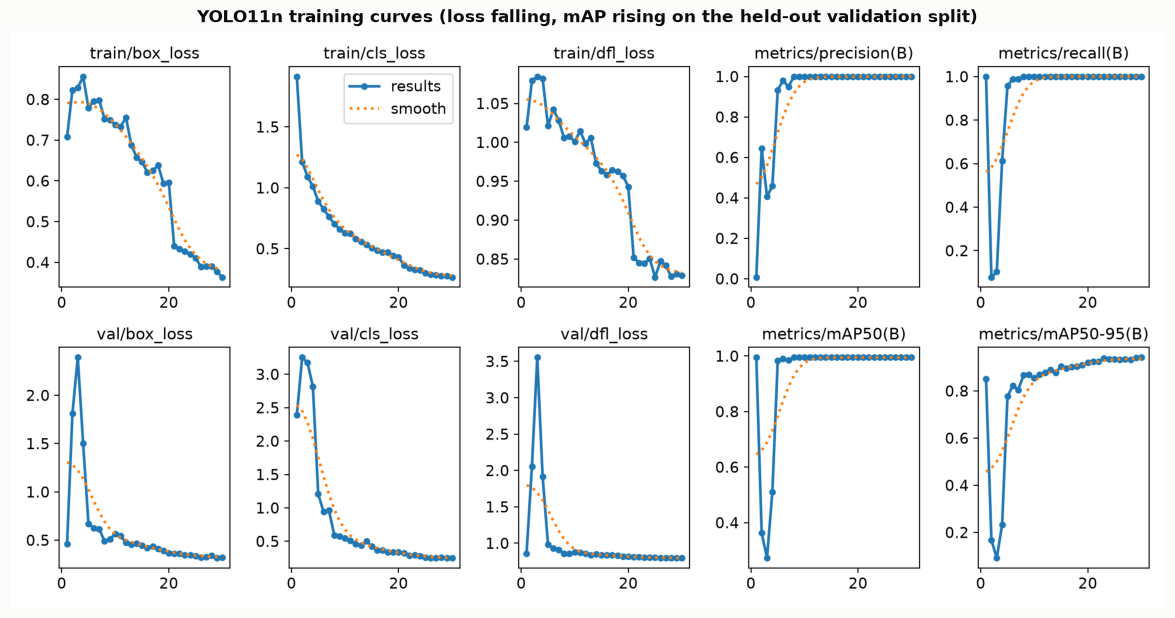

In [15]:
if not (config.YOLO_DIR / "data.yaml").exists():
    t0 = time.time()
    make_yolo_dataset(config.YOLO_DIR, workers=WORKERS)
    print(f"YOLO training set written in {time.time() - t0:.0f}s")
if TRAIN_YOLO and not config.YOLO_WEIGHTS.exists():
    try:
        t0 = time.time()
        train_yolo(config.YOLO_DIR / "data.yaml", epochs=YOLO_EPOCHS, project=config.OUTPUT_DIR / "yolo")
        print(f"trained in {(time.time() - t0) / 60:.1f} min")
    except Exception as e:
        print("YOLO training skipped:", e)
detector = LabelDetector(config.YOLO_WEIGHTS)
print("Active detector:", detector.name, "|", config.YOLO_WEIGHTS if detector.name == "yolo" else "classical fallback")
curves = config.YOLO_WEIGHTS.parent.parent / "results.png"
if curves.exists():
    plt.figure(figsize=(15, 7.5)); plt.imshow(plt.imread(curves)); plt.axis("off")
    plt.title("YOLO11n training curves (loss falling, mAP rising on the held-out validation split)"); plt.show()

## 4. ROI preprocessing: the Geometric Pre-Processing & Attention-Crop layer (our contribution)

Slide 6 asks for an *OCR-ready ROI*: enough pixels per character, grayscale, contrast enhancement, denoising,
thresholding, and **perspective correction for angled labels**. This layer does all of that, and goes further on
the geometry, which is where out-of-the-box OCR fails. Why each step exists:

* **Segmentation from a border model.** The camera watches a fixed scan area, so the frame border is background. Every pixel
  is scored by its CIE-Lab distance from the median border colour. Darker-than-mat differences are down-weighted so the
  object's drop shadow is not merged into it. Plain and inverted Otsu masks compete, and the most rectangular blob wins,
  which also covers phone photos where the label touches the frame edge.
* **Quad + homography.** A rotation (what the first prototype did) cannot undo camera tilt, which turns the label into a
  trapezoid. Four corners and `warpPerspective` remove rotation and keystone in one step. Corners are ordered so the long
  edge is horizontal.
* **Boundary-guided dewarp.** On a bent label the top and bottom edges are curves `t(x)`, `b(x)`. We fit them with
  outlier-rejecting polynomials and resample each column so `t(x)`→0 and `b(x)`→H. If the fit is poor (shadow or glare
  bites into the mask) the step is skipped, never applied blindly.
* **Projection-profile skew (discrete Radon).** At the right angle the horizontal ink profile is spikiest (maximum variance).
  This removes the ±1–5° left after the warp, and becomes a full ±90° deskew when no border is found at all.
* **Attention crops.** Long rules, borders and big blobs (QR codes) are removed, then lines are cut from the ink profile.
  Pixels outside dilated character strokes are painted white, and each line's ink centroid curve is flattened.

In [16]:
@dataclass
class Geometry:
    found: bool = False
    quad: np.ndarray | None = None          # 4x2 corners in input-frame pixels (ordered, long edge first)
    mask: np.ndarray | None = None
    method: str = ""
    rectangularity: float = 0.0
    stages: dict = field(default_factory=dict)


def resize_max(img: np.ndarray, max_side: int = config.MAX_SIDE) -> np.ndarray:
    h, w = img.shape[:2]
    s = max_side / max(h, w)
    return cv2.resize(img, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA) if s < 1 else img


def _largest_blob(mask: np.ndarray):
    cnts, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None, 0.0
    c = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(c)
    (_, _), (w, h), _ = cv2.minAreaRect(c)
    rect = area / (w * h + 1e-6)
    return c, rect


def segment_object(img: np.ndarray) -> tuple[np.ndarray, str, float]:
    """Return a binary mask of the object on the scan mat.

    Two candidate masks are built and the more rectangular one wins:
      a) colour distance (CIE-Lab) from the median *border* colour - works for any object colour
         because the camera looks at a fixed scan area whose edges are background;
      b) plain Otsu on brightness - works when the label touches the frame border (phone photos).
    """
    h, w = img.shape[:2]
    s = 640 / max(h, w)
    small = cv2.resize(img, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA)
    small = cv2.GaussianBlur(small, (5, 5), 0)
    lab = cv2.cvtColor(small, cv2.COLOR_RGB2LAB).astype(np.float32)
    b = 8
    border = np.concatenate([lab[:b].reshape(-1, 3), lab[-b:].reshape(-1, 3), lab[:, :b].reshape(-1, 3), lab[:, -b:].reshape(-1, 3)])
    med = np.median(border, axis=0)
    spread = np.median(np.abs(border - med), axis=0) + 1.0
    d = (lab - med) / spread
    # shadows are a *darker* version of the mat: down-weight negative lightness differences so
    # the drop shadow is not merged into the object mask
    dL = np.where(d[..., 0] > 0, d[..., 0], 0.3 * d[..., 0])
    dist = np.sqrt(dL ** 2 + d[..., 1] ** 2 + d[..., 2] ** 2)
    dist = cv2.normalize(dist, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, m_color = cv2.threshold(dist, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    gray = cv2.cvtColor(small, cv2.COLOR_RGB2GRAY)
    _, m_bright = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    best = (None, "", -1.0)
    for name, m in (("lab-border", m_color), ("otsu", m_bright), ("otsu-inv", 255 - m_bright)):
        m = cv2.morphologyEx(m, cv2.MORPH_OPEN, k, iterations=2)
        m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, k, iterations=3)
        c, rect = _largest_blob(m)
        if c is None:
            continue
        frac = cv2.contourArea(c) / (m.shape[0] * m.shape[1])
        if frac < config.MIN_OBJECT_FRAC or frac > 0.92:
            continue
        filled = np.zeros_like(m)
        cv2.drawContours(filled, [c], -1, 255, -1)
        if rect > best[2]:
            best = (filled, name, rect)
    if best[0] is None:
        return np.zeros((h, w), np.uint8), "none", 0.0
    full = cv2.resize(best[0], (w, h), interpolation=cv2.INTER_NEAREST)
    return full, best[1], best[2]


def order_quad(pts: np.ndarray) -> np.ndarray:
    """Order 4 points clockwise starting so that edge 0->1 is a LONG edge (landscape output)."""
    pts = np.asarray(pts, np.float32).reshape(4, 2)
    c = pts.mean(0)
    ang = np.arctan2(pts[:, 1] - c[1], pts[:, 0] - c[0])
    pts = pts[np.argsort(ang)]                      # clockwise in image coords (y down)
    e = [np.linalg.norm(pts[(i + 1) % 4] - pts[i]) for i in range(4)]
    if e[0] + e[2] < e[1] + e[3]:
        pts = np.roll(pts, -1, axis=0)
    # of the two long-edge choices, start from the one whose first edge is the "top" (smaller y);
    # remaining 180-degree ambiguity is settled later by OCR confidence
    alt = np.roll(pts, -2, axis=0)
    if (alt[0][1] + alt[1][1]) < (pts[0][1] + pts[1][1]):
        pts = alt
    return pts


def _quad_iou(quad: np.ndarray, mask: np.ndarray) -> float:
    poly = np.zeros_like(mask)
    cv2.fillPoly(poly, [quad.astype(np.int32)], 255)
    inter = np.logical_and(poly > 0, mask > 0).sum()
    union = np.logical_or(poly > 0, mask > 0).sum()
    return inter / max(union, 1)


def find_label_quad(mask: np.ndarray) -> np.ndarray | None:
    """Two corner hypotheses: a 4-vertex polygon fit (captures perspective) and the min-area
    rectangle (robust when glare/shadow bites into the mask). Keep whichever overlaps the
    object mask better (IoU)."""
    c, _ = _largest_blob(mask)
    if c is None:
        return None
    # labels are (nearly) convex: the hull fills bites left by glare, dark print and QR codes
    hull_mask = np.zeros_like(mask)
    cv2.fillPoly(hull_mask, [cv2.convexHull(c)], 255)
    mask = hull_mask
    box = order_quad(cv2.boxPoints(cv2.minAreaRect(c)))
    hull = cv2.convexHull(c)
    peri = cv2.arcLength(hull, True)
    poly = None
    for eps in np.linspace(0.01, 0.08, 15):
        approx = cv2.approxPolyDP(hull, eps * peri, True)
        if len(approx) == 4:
            poly = order_quad(approx.reshape(4, 2))
            break
    if poly is None or not cv2.isContourConvex(poly.astype(np.int32)):
        return box
    return poly if _quad_iou(poly, mask) >= _quad_iou(box, mask) - 0.01 else box


def locate(img: np.ndarray) -> Geometry:
    g = Geometry()
    mask, method, rect = segment_object(img)
    g.mask, g.method, g.rectangularity = mask, method, rect
    if method == "none":
        return g
    quad = find_label_quad(mask)
    if quad is None:
        return g
    g.quad, g.found = quad, True
    return g

In [17]:
def rectify(img: np.ndarray, quad: np.ndarray, mask: np.ndarray | None = None,
            out_h: int = config.LABEL_HEIGHT, margin: float = 0.18):
    """Perspective-warp the quad to a frontal rectangle of height out_h. A vertical margin is
    kept so that a bent label whose edges bow outside its corner points is not clipped."""
    w_len = (np.linalg.norm(quad[1] - quad[0]) + np.linalg.norm(quad[2] - quad[3])) / 2
    h_len = (np.linalg.norm(quad[3] - quad[0]) + np.linalg.norm(quad[2] - quad[1])) / 2
    out_w = int(round(out_h * w_len / max(h_len, 1)))
    out_w = int(np.clip(out_w, out_h, out_h * 6))
    m = int(margin * out_h)
    dst = np.array([[0, m], [out_w, m], [out_w, m + out_h], [0, m + out_h]], np.float32)
    H = cv2.getPerspectiveTransform(quad.astype(np.float32), dst)
    size = (out_w, out_h + 2 * m)
    warped = cv2.warpPerspective(img, H, size, flags=cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    wmask = cv2.warpPerspective(mask, H, size, flags=cv2.INTER_NEAREST) if mask is not None else None
    return warped, wmask, m


def _robust_poly(x, y, x_eval, deg: int = 3, iters: int = 3):
    """Polynomial fit with iterative MAD outlier rejection. Returns (curve, residual MAD)."""
    keep = np.ones(len(x), bool)
    for _ in range(iters):
        p = np.polyfit(x[keep], y[keep], deg)
        res = np.abs(np.polyval(p, x) - y)
        mad = np.median(res[keep]) + 1e-6
        new = res < max(2.5 * 1.4826 * mad, 1.5)
        if new.sum() < 0.3 * len(x) or (new == keep).all():
            break
        keep = new
    return np.polyval(p, x_eval), float(np.median(res[keep]))


def boundary_dewarp(img: np.ndarray, wmask: np.ndarray, margin: int, out_h: int = config.LABEL_HEIGHT,
                    min_bow_px: float = 3.0):
    """Estimate the label's top edge t(x) and bottom edge b(x) from the warped mask, fit smooth
    polynomials, and resample every column so that t(x)->0 and b(x)->out_h. This flattens
    cylindrical bending and low-frequency crumpling that a single homography cannot remove."""
    H, W = wmask.shape
    xs = np.arange(W)
    col = wmask > 0
    has = col.any(0)
    top = np.where(has, col.argmax(0), np.nan).astype(np.float64)
    bot = np.where(has, H - 1 - col[::-1].argmax(0), np.nan).astype(np.float64)
    valid = has & (bot - top > 0.5 * out_h)
    valid[: int(0.03 * W)] = False
    valid[-int(0.03 * W) - 1:] = False
    if valid.sum() < 0.4 * W:
        return img[margin:margin + out_h], False, None
    t, rt = _robust_poly(xs[valid], top[valid], xs)
    b, rb = _robust_poly(xs[valid], bot[valid], xs)
    bow = max(np.ptp(t), np.ptp(b))
    # only trust the edge curves if they fit cleanly (no shadow/glare bites out of the mask)
    if bow < min_bow_px or max(rt, rb) > 3.0:
        return img[margin:margin + out_h], False, (t, b)
    r = np.arange(out_h, dtype=np.float64)[:, None] / (out_h - 1)
    map_y = (t[None, :] + r * (b - t)[None, :]).astype(np.float32)
    map_x = np.tile(xs.astype(np.float32), (out_h, 1))
    out = cv2.remap(img, map_x, map_y, cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)
    return out, True, (t, b)

In [18]:
def normalize(rgb: np.ndarray) -> tuple[np.ndarray, bool]:
    """Gray + CLAHE; invert if the text is lighter than its background (PCB silkscreen)."""
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY) if rgb.ndim == 3 else rgb
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 8))
    g = clahe.apply(gray)
    h, w = g.shape
    core = g[int(0.1 * h):int(0.9 * h), int(0.05 * w):int(0.95 * w)]
    t, _ = cv2.threshold(core, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bright_frac = (core > t).mean()
    inverted = bright_frac < 0.5      # the minority class is text; if bright pixels are the minority -> light text
    if inverted:
        g = 255 - g
    return g, inverted


def binarize(gray: np.ndarray) -> np.ndarray:
    """Text = 255. Sauvola-like local threshold that survives glare on metal plates."""
    bs = max(15, (gray.shape[0] // 8) | 1)
    return cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, bs, 12)


def radon_skew(binary: np.ndarray, max_angle: float = 8.0, step: float = 0.5) -> float:
    """Projection-profile skew estimate: the angle whose horizontal projection (one row of the
    discrete Radon transform) has maximum variance is the angle at which text lines are level.
    Use max_angle=90 as a stand-alone deskew when no label border can be detected at all."""
    h, w = binary.shape
    s = min(1.0, 500 / max(h, w))
    small = cv2.resize(binary, (int(w * s), int(h * s)), interpolation=cv2.INTER_AREA)
    c = (small.shape[1] / 2, small.shape[0] / 2)
    best, best_score = 0.0, -1.0
    for a in np.arange(-max_angle, max_angle + 1e-6, step):
        M = cv2.getRotationMatrix2D(c, a, 1.0)
        rot = cv2.warpAffine(small, M, (small.shape[1], small.shape[0]), flags=cv2.INTER_NEAREST)
        prof = rot.sum(1).astype(np.float64)
        score = np.var(prof)
        if score > best_score:
            best, best_score = float(a), score
    return best


def rotate(img: np.ndarray, angle: float, border=255) -> np.ndarray:
    if abs(angle) < 1e-3:
        return img
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h), flags=cv2.INTER_CUBIC, borderValue=border)

In [19]:
def _split_band(prof: np.ndarray, y0: int, y1: int, h: int, max_frac: float = 0.24):
    """Recursively split a tall band at its deepest interior valley (two text lines that touch
    in the profile because of descenders, slight residual skew or line spacing)."""
    if y1 - y0 <= max_frac * h:
        return [(y0, y1)]
    seg = prof[y0:y1]
    lo, hi = int(0.2 * len(seg)), int(0.8 * len(seg))
    k = lo + int(np.argmin(seg[lo:hi]))
    if seg[k] > 0.4 * seg.max():
        return [(y0, y1)]
    return _split_band(prof, y0, y0 + k, h, max_frac) + _split_band(prof, y0 + k, y1, h, max_frac)


def segment_lines(binary: np.ndarray, min_h_frac: float = 0.07, max_lines: int = 6):
    """Return [(y0, y1, x0, x1)] text-line boxes from the horizontal ink profile."""
    h, w = binary.shape
    b = binary.copy()
    # remove long horizontal/vertical rules (label borders, header bars) that would merge lines
    horiz = cv2.morphologyEx(b, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (w // 4, 1)))
    vert = cv2.morphologyEx(b, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_RECT, (1, h // 3)))
    b = cv2.subtract(b, cv2.bitwise_or(horiz, vert))
    b[:, : int(0.015 * w)] = 0
    b[:, -int(0.015 * w) - 1:] = 0
    # keep only character-sized components: drops QR codes, logos and big blobs (too tall),
    # PCB traces and rules (too flat), pads/vias/rivets/specks (too small)
    n, lab, st, _ = cv2.connectedComponentsWithStats(b, 8)
    char = np.zeros(n, bool)   # used to LOCATE lines
    small = np.ones(n, bool)   # everything but big blobs: kept in the OCR mask (dashes survive)
    small[0] = False
    for i in range(1, n):
        x, y, bw, bh, area = st[i]
        fill = area / max(bw * bh, 1)
        if bh > 0.33 * h:
            small[i] = False
        if 0.055 * h <= bh <= 0.33 * h and bw <= 0.2 * w and 0.08 < fill < 0.97 and bw <= 3 * bh:
            char[i] = True
    b_ocr = np.where(small[lab], b, 0).astype(np.uint8)
    b = np.where(char[lab], b, 0).astype(np.uint8)
    prof = (b > 0).sum(1).astype(np.float64)
    prof = np.convolve(prof, np.ones(5) / 5, mode="same")
    thr = max(2.0, 0.08 * prof.max())
    on = prof > thr
    bands = []
    y = 0
    while y < h:
        if on[y]:
            y0 = y
            while y < h and on[y]:
                y += 1
            bands.extend(_split_band(prof, y0, y, h))
        y += 1
    boxes = []
    for y0, y1 in bands:
        if (y1 - y0) >= min_h_frac * h:
            cols = np.where((b[y0:y1] > 0).sum(0) > 0)[0]
            if len(cols):
                boxes.append((y0, y1, int(cols[0]), int(cols[-1]) + 1))
    boxes.sort(key=lambda bx: -(bx[1] - bx[0]) * (bx[3] - bx[2]))
    return boxes[:max_lines], b_ocr


def mask_to_text(line_gray: np.ndarray, line_bin: np.ndarray) -> np.ndarray:
    """Attention mask: keep only pixels near detected character strokes and paint everything
    else (label borders, rivets, QR fragments, folds) white, then stretch contrast."""
    if line_bin.sum() == 0:
        return line_gray
    h = line_bin.shape[0]
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (max(3, h // 10) | 1, max(3, h // 10) | 1))
    keep = cv2.dilate(line_bin, k) > 0
    out = np.full_like(line_gray, 255)
    out[keep] = line_gray[keep]
    lo, hi = np.percentile(line_gray[keep], [2, 98]) if keep.any() else (0, 255)
    out = np.clip((out.astype(np.float32) - lo) * 255.0 / max(hi - lo, 1), 0, 255).astype(np.uint8)
    out[~keep] = 255
    return out


def baseline_dewarp(line_gray: np.ndarray, line_bin: np.ndarray, deg: int = 2) -> np.ndarray:
    """Fit the per-column ink centroid with a low-order polynomial and shift columns so the
    centroid curve becomes a straight line (residual curvature inside one text line)."""
    h, w = line_bin.shape
    ink = line_bin > 0
    cnt = ink.sum(0)
    valid = cnt > 0
    if valid.sum() < 0.3 * w:
        return line_gray
    ys = np.arange(h)[:, None]
    cen = (ink * ys).sum(0) / np.maximum(cnt, 1)
    xs = np.arange(w)
    p = np.polyfit(xs[valid], cen[valid], deg, w=np.sqrt(cnt[valid]))
    curve = np.polyval(p, xs)
    shift = curve - curve.mean()
    if np.ptp(shift) < 2:
        return line_gray
    map_x = np.tile(xs.astype(np.float32), (h, 1))
    map_y = (np.arange(h, dtype=np.float32)[:, None] + shift[None, :]).astype(np.float32)
    return cv2.remap(line_gray, map_x, map_y, cv2.INTER_CUBIC, borderMode=cv2.BORDER_REPLICATE)


def pad_for_ocr(gray: np.ndarray, target_h: int = 64, pad: int = 12) -> np.ndarray:
    """Resize a line crop to a text height Tesseract likes and add white padding."""
    h, w = gray.shape[:2]
    s = target_h / max(h, 1)
    g = cv2.resize(gray, (max(1, int(w * s)), target_h), interpolation=cv2.INTER_CUBIC)
    return cv2.copyMakeBorder(g, pad, pad, pad, pad, cv2.BORDER_CONSTANT, value=255)

In [20]:
def rotation_only_deskew(img: np.ndarray) -> np.ndarray:
    """What the first prototype did: Otsu -> largest contour -> minAreaRect angle -> rotate frame.
    Kept for the ablation study (no perspective, no dewarp, no crop, no orientation check)."""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return img
    box = cv2.boxPoints(cv2.minAreaRect(max(cnts, key=cv2.contourArea)))
    edges = [box[(i + 1) % 4] - box[i] for i in range(4)]
    dx, dy = max(edges, key=lambda e: np.hypot(*e))           # long side of the rectangle
    angle = math.degrees(math.atan2(dy, dx))                   # y-down: positive = clockwise tilt
    angle = (angle + 90) % 180 - 90                            # wrap to [-90, 90)
    M = cv2.getRotationMatrix2D((img.shape[1] / 2, img.shape[0] / 2), angle, 1.0)
    return cv2.warpAffine(img, M, (img.shape[1], img.shape[0]), borderMode=cv2.BORDER_REPLICATE)


def draw_quad(img: np.ndarray, quad: np.ndarray, color=(42, 120, 214)) -> np.ndarray:
    out = img.copy()
    q = quad.astype(np.int32)
    t = max(2, img.shape[1] // 300)
    cv2.polylines(out, [q], True, color, t, cv2.LINE_AA)
    for i, p in enumerate(q):
        cv2.circle(out, tuple(int(v) for v in p), 3 * t, (235, 104, 52) if i == 0 else color, -1, cv2.LINE_AA)
    return out

### Detection → ROI on held-out test frames
Green = detector box (its confidence), orange dashed = ground-truth label box. The classical locator above is the fallback.

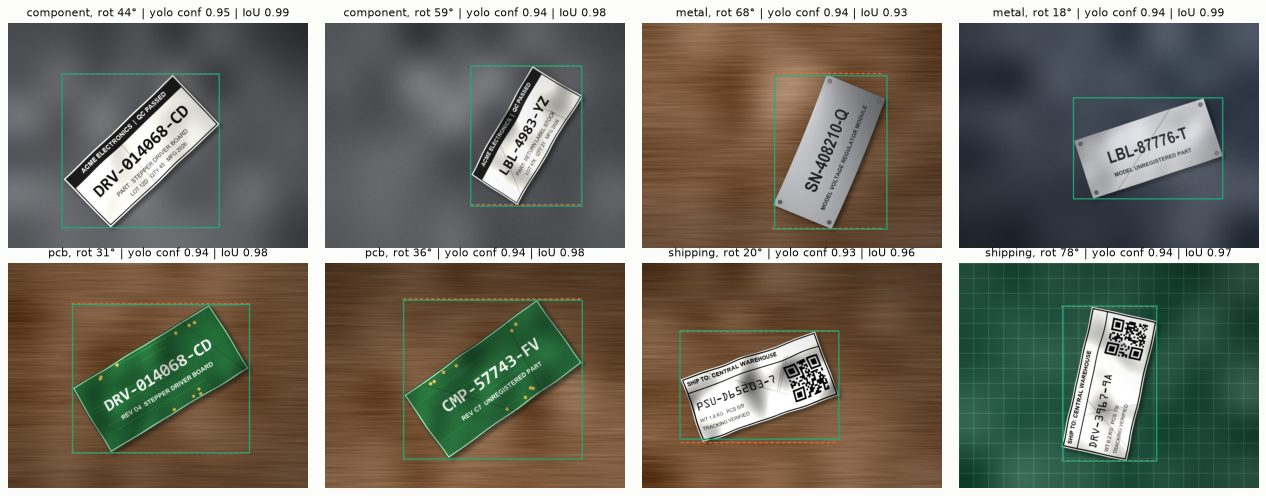

In [21]:
# detections on evaluation images the detector never saw (green = YOLO box, orange dashed = ground truth)
sel = ann.groupby("template").sample(2, random_state=3)
vis, titles = [], []
for row in sel.itertuples():
    img = load_rgb(config.SYNTH_DIR / row.filename)
    gt = corners_to_bbox(parse_corners(row.corners))
    box, conf, src = detector.detect(img)
    v = img.copy()
    for k in range(0, int(gt[2] - gt[0]), 24):   # dashed ground-truth box
        cv2.line(v, (int(gt[0]) + k, int(gt[1])), (int(min(gt[2], gt[0] + k + 12)), int(gt[1])), (235, 104, 52), 3)
        cv2.line(v, (int(gt[0]) + k, int(gt[3])), (int(min(gt[2], gt[0] + k + 12)), int(gt[3])), (235, 104, 52), 3)
    if box is not None:
        cv2.rectangle(v, (int(box[0]), int(box[1])), (int(box[2]), int(box[3])), (27, 175, 122), 4)
    vis.append(v)
    titles.append(f"{row.template}, rot {row.angle:.0f}° | {src} conf {conf:.2f} | IoU {bbox_iou(box, gt) if box else 0:.2f}")
show_images(vis, titles, cols=4, size=4.0, save="yolo_detections.png")

## 5. OCR, serial extraction & text normalisation

Slide 7: *OCR performs character recognition; verification decides whether the result is acceptable.* The geometric layer
does not depend on the engine. Tesseract is the default (fast, CPU-only). EasyOCR and PaddleOCR
plug into the same two calls: `read_line(crop)` for an attention crop and `read_page(frame)` for the baseline.

*Implementation note:* with a character whitelist, Tesseract 5 reports confidence 0 for every word, and the
retry/orientation logic needs real confidences. So we read with the full alphabet and map the result onto the serial
alphabet afterwards, fixing common glyph confusions (slashed zero read as `@`/`Ø`, `§`→`S`, and so on). Baseline and
pipeline use exactly the same serial extraction.

In [22]:
@dataclass
class OCRToken:
    text: str
    conf: float  # 0..100


class OCREngine:
    name = "base"

    def read_line(self, img: np.ndarray) -> OCRToken:
        """Read a single, already-cropped text line."""
        raise NotImplementedError

    def read_page(self, img: np.ndarray) -> list[OCRToken]:
        """Read an uncropped frame (used by the baseline): every text fragment found."""
        raise NotImplementedError


class TesseractEngine(OCREngine):
    name = "tesseract"

    # NOTE: Tesseract 5 reports conf=0 for every word when tessedit_char_whitelist is set, and
    # the retry/orientation logic needs real confidences. So we read with the full alphabet and
    # restrict to the serial alphabet afterwards (clean()), dropping low-confidence specks.
    def __init__(self, whitelist: str | None = None, min_word_conf: float = 30.0):
        import pytesseract
        self.min_word_conf = min_word_conf
        self.pt = pytesseract
        for cand in config.TESSERACT_CMD_CANDIDATES:
            if cand and (Path(cand).exists() or shutil.which(cand)):
                pytesseract.pytesseract.tesseract_cmd = cand
                break
        wl = f" -c tessedit_char_whitelist={whitelist}" if whitelist else ""
        self.line_cfg = "--oem 1 --psm 7" + wl
        self.page_cfg = "--oem 1 --psm 11" + wl

    def _data(self, img, cfg):
        try:
            d = self.pt.image_to_data(img, config=cfg, output_type=self.pt.Output.DICT)
        except Exception:      # a crashed/killed tesseract call = "nothing read", never a crash
            return []
        return [(t.strip(), float(c), d["block_num"][i], d["line_num"][i])
                for i, (t, c) in enumerate(zip(d["text"], d["conf"])) if t.strip() and float(c) >= 0]

    def read_line(self, img):
        words = self._data(img, self.line_cfg)
        strong = [w for w in words if w[1] >= self.min_word_conf and clean(w[0])]
        words = strong or words
        if not words:
            return OCRToken("", 0.0)
        return OCRToken(" ".join(w[0] for w in words), float(np.mean([w[1] for w in words])))

    def read_page(self, img):
        return [OCRToken(w[0], w[1]) for w in self._data(img, self.page_cfg)]


class EasyOCREngine(OCREngine):
    name = "easyocr"
    _reader = None

    def __init__(self, whitelist: str | None = config.SERIAL_ALPHABET, gpu: bool = False):
        import easyocr
        if EasyOCREngine._reader is None:
            # quantize=False: EasyOCR's dynamic int8 quantisation crashes ("ChooseQuantizationParams")
            # when OMP_THREAD_LIMIT is set, which we do for parallel Tesseract
            EasyOCREngine._reader = easyocr.Reader(["en"], gpu=gpu, verbose=False, quantize=False)
        self.reader = EasyOCREngine._reader
        self.allow = whitelist

    def read_line(self, img):
        res = self.reader.readtext(img, allowlist=self.allow, detail=1, paragraph=False)
        if not res:
            return OCRToken("", 0.0)
        res.sort(key=lambda r: min(p[0] for p in r[0]))  # left-to-right
        return OCRToken(" ".join(r[1] for r in res), 100 * float(np.mean([r[2] for r in res])))

    def read_page(self, img):
        return [OCRToken(r[1].replace(" ", ""), 100 * float(r[2]))
                for r in self.reader.readtext(img, allowlist=self.allow, detail=1)]


class PaddleOCREngine(OCREngine):
    """Optional: pip install paddlepaddle paddleocr. Not required for the rest of the project."""
    name = "paddleocr"

    def __init__(self, whitelist=None):
        from paddleocr import PaddleOCR
        self.ocr = PaddleOCR(use_angle_cls=False, lang="en", show_log=False)

    def _run(self, img):
        out = self.ocr.ocr(img, cls=False) or [[]]
        return [OCRToken(re.sub(r"\s", "", r[1][0]).upper(), 100 * float(r[1][1])) for r in (out[0] or [])]

    def read_line(self, img):
        toks = self._run(img)
        if not toks:
            return OCRToken("", 0.0)
        return OCRToken(" ".join(t.text for t in toks), float(np.mean([t.conf for t in toks])))

    def read_page(self, img):
        return self._run(img)


def get_engine(name: str | None = None) -> OCREngine:
    name = (name or "tesseract").lower()
    if name == "tesseract":
        return TesseractEngine()
    if name == "easyocr":
        return EasyOCREngine()
    if name in ("paddle", "paddleocr"):
        return PaddleOCREngine()
    raise ValueError(f"unknown OCR engine {name!r}")

**Normalisation before verification (slide 7):** standardise case → fix glyph confusions → remove separators and spaces
(spaces around dashes are closed up, other gaps split words) → **format check** against the serial pattern
`AA(AA)-NNNN(NNN)-X(XX)`. Only text that passes the format check is treated as a well-formed serial. Anything else is
an incomplete read, which leads to **ERROR / re-capture** (§7).

In [23]:
_SERIAL_RE = re.compile(config.SERIAL_REGEX)


_CONFUSIONS = str.maketrans({"@": "0", "Ø": "0", "ø": "0", "§": "S", "$": "S", "—": "-", "–": "-",
                             "_": "-", "~": "-", "=": "-", "€": "E"})


def clean(text: str) -> str:
    return re.sub(r"[^A-Z0-9-]", "", text.translate(_CONFUSIONS).upper())


def extract_serial(tokens: list[OCRToken]) -> tuple[str, float]:
    """Pick the most serial-looking string from a list of OCR fragments.
    Returns (serial, confidence). Never looks at ground truth."""
    best, best_score, best_conf = "", -1.0, 0.0
    for t in tokens:
        for c in candidates(t.text):
            cand, score = _score_candidate(c, t.conf)
            if score > best_score:
                best, best_score, best_conf = cand, score, t.conf
    return best, best_conf


def candidates(text: str) -> list[str]:
    """Word-level candidates. Spaces around dashes are closed up ("CTL - 4411 - B" is one
    serial) but other word gaps are kept, so stray specks are not glued onto a serial."""
    t = re.sub(r"\s*[-—–_~=]\s*", "-", text.strip())
    words = [clean(w) for w in t.split()]
    words = [w for w in words if w]
    out = list(words)
    out += [a + b for a, b in zip(words, words[1:])]   # serial split by one bogus space
    return out


def _score_candidate(c: str, conf: float) -> tuple[str, float]:
    m = _SERIAL_RE.search(c)
    if m and m.start() == 0 and m.end() == len(c):
        return c, 200 + conf
    if m:
        return m.group(0), 190 + conf
    cand = c.strip("-")
    digits = sum(ch.isdigit() for ch in cand)
    # a serial-like fragment has digits and dashes; plain words ("TRACKING") score low
    score = 20 * min(cand.count("-"), 2) + 6 * min(digits, 6) + 0.2 * conf
    if not (6 <= len(cand) <= 16):
        score *= 0.5
    return cand, score


def looks_like_serial(text: str) -> bool:
    return any(_SERIAL_RE.fullmatch(c) for c in candidates(text))

In [24]:
for raw in ["cmp - 006459 - z", "CTL-P38219-@Y", "PSU-H254-L3 ij", "S/N: SN 284517 XJ", "PART: MOTOR CONTROLLER", "7~"]:
    serial, _ = extract_serial([OCRToken(raw, 90.0)])
    print(f"raw OCR {raw!r:28} -> normalised {serial!r:16} format check: {'OK' if looks_like_serial(serial) else 'FAIL'}")

engine = get_engine("tesseract")
probe = render_label("SN-284517-XJ", "component", "Voltage Regulator Module", random.Random(1))
toks = engine.read_page(probe)
print("\nTesseract fragments on a flat label:", [(t.text, round(t.conf)) for t in toks][:8])
print("extracted serial:", extract_serial(toks))

raw OCR 'cmp - 006459 - z'           -> normalised 'CMP-006459-Z'   format check: OK
raw OCR 'CTL-P38219-@Y'              -> normalised 'CTL-P38219-0Y'  format check: OK
raw OCR 'PSU-H254-L3 ij'             -> normalised 'PSU-H254-L3'    format check: OK
raw OCR 'S/N: SN 284517 XJ'          -> normalised '284517'         format check: FAIL
raw OCR 'PART: MOTOR CONTROLLER'     -> normalised 'CONTROLLER'     format check: FAIL
raw OCR '7~'                         -> normalised '7'              format check: FAIL



Tesseract fragments on a flat label: [('ACME', 93), ('ELECTRONICS', 93), ('|', 96), ('QC', 96), ('PASSED', 96), ('SN-284517-XJ', 40), ('PART:', 95), ('VOLTAGE', 95)]
extracted serial: ('SN-284517-XJ', 40.0)


## 6. Module integration: the three readers compared

* `read_baseline`: raw frame → OCR (what you get out of the box).
* `read_rotation_only`: the first prototype (Otsu → `minAreaRect` → rotate whole frame → OCR).
* `read_label`: **YOLO → ROI → full geometric layer → OCR**. `PipelineOptions` turns each stage off for the ablation in §10.5.

**Confidence-guided retry:** an attention crop that does not read as a confident serial is re-read at other text heights
(64 → 48 → 84 px), and the best-scoring attempt is kept. **Orientation:** after rectification the label is level but may be
upside-down. We read both orientations and keep the one whose *whole label* reads more confidently. Upright lines like
"PART: …" read at ~95 % confidence; upside-down ones read as junk at ~50 %.

In [25]:
@dataclass
class ReadResult:
    serial: str
    conf: float
    method: str
    tokens: list = field(default_factory=list)
    stages: dict = field(default_factory=dict)
    timings: dict = field(default_factory=dict)
    notes: list = field(default_factory=list)


@dataclass
class PipelineOptions:
    perspective: bool = True      # 4-corner homography instead of rotation only
    dewarp: bool = True           # boundary-guided column dewarp (bending / crumple)
    radon: bool = True            # residual-skew correction
    line_crops: bool = True       # attention crops per text line (+ baseline dewarp)
    orientation: bool = True      # 0 / 180 degree disambiguation by OCR confidence
    keep_stages: bool = False


def read_baseline(img: np.ndarray, engine: OCREngine) -> ReadResult:
    t0 = time.perf_counter()
    toks = engine.read_page(resize_max(img))
    serial, conf = extract_serial(toks)
    return ReadResult(serial, conf, "baseline", toks, timings={"ocr": time.perf_counter() - t0})


def read_rotation_only(img: np.ndarray, engine: OCREngine) -> ReadResult:
    t0 = time.perf_counter()
    img = resize_max(img)
    fixed = rotation_only_deskew(img)
    t1 = time.perf_counter()
    toks = engine.read_page(fixed)
    serial, conf = extract_serial(toks)
    return ReadResult(serial, conf, "rotation_only", toks, stages={"deskewed": fixed},
                      timings={"geometry": t1 - t0, "ocr": time.perf_counter() - t1})


def _score(serial: str, conf: float) -> float:
    return (200 if looks_like_serial(serial) else 0) + conf

In [26]:
RETRY_HEIGHTS = (64, 48, 84)


def _read_line_retry(gray_line: np.ndarray, engine: OCREngine, good_conf: float = 80.0):
    """Confidence-guided retry: if the read is not a confident serial, re-read the same crop at
    other text heights and keep the best scoring attempt."""
    best = None
    for th in RETRY_HEIGHTS:
        crop = pad_for_ocr(gray_line, target_h=th)
        tok = engine.read_line(crop)
        sc = _score(tok.text, tok.conf)
        if best is None or sc > best[0]:
            best = (sc, tok, crop)
        if looks_like_serial(tok.text) and tok.conf >= good_conf:
            break
        if not looks_like_serial(tok.text) and tok.conf >= 85:
            break  # a confidently-read non-serial line (e.g. "PART: ...") - no point retrying
    return best[1], best[2]


def _read_oriented(gray: np.ndarray, engine: OCREngine, opts: PipelineOptions, stages: dict | None, tag: str):
    """OCR one orientation of the rectified label. Returns (serial, conf, tokens)."""
    binary = binarize(gray)
    tokens: list[OCRToken] = []
    if opts.line_crops:
        boxes, clean_bin = segment_lines(binary)
        h, w = gray.shape
        crops = []
        for (y0, y1, x0, x1) in boxes[:3]:
            m = int(0.18 * (y1 - y0)) + 2
            ya, yb = max(0, y0 - m), min(h, y1 + m)
            xa, xb = max(0, x0 - m), min(w, x1 + m)
            g, bn = gray[ya:yb, xa:xb], clean_bin[ya:yb, xa:xb]
            g = mask_to_text(g, bn)
            g = baseline_dewarp(g, bn)
            tok, crop = _read_line_retry(g, engine)
            crops.append(crop)
            tokens.append(tok)
            if looks_like_serial(tokens[-1].text) and tokens[-1].conf > 85:
                break  # confident serial found: skip the remaining lines
        if stages is not None:
            vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
            for i, (y0, y1, x0, x1) in enumerate(boxes[:3]):
                cv2.rectangle(vis, (x0, y0), (x1, y1), (42, 120, 214) if i == 0 else (235, 104, 52), 2)
            stages[f"lines{tag}"] = vis
            stages[f"crops{tag}"] = crops
    if not tokens or not any(looks_like_serial(t.text) for t in tokens):
        tokens += engine.read_page(pad_for_ocr(gray, target_h=gray.shape[0]))
    serial, conf = extract_serial(tokens)
    # orientation evidence = how confidently the *whole label* reads (upright "PART: ..." lines
    # read at ~95, upside-down ones at ~50), not just the serial line
    # (symmetric glyphs like OCR-A digits can read "confidently" upside-down, plain text can't)
    others = [t.conf for t in tokens if t.text.strip() and (not serial or serial not in clean(t.text))]
    line_conf = float(np.mean(others)) if others else conf
    return serial, conf, tokens, line_conf


def read_label(img: np.ndarray, engine: OCREngine, opts: PipelineOptions | None = None,
               detector="default") -> ReadResult:
    if isinstance(detector, str):
        detector = globals().get("detector")
    opts = opts or PipelineOptions()
    T = {}
    stages: dict | None = {} if opts.keep_stages else None
    notes = []
    t = time.perf_counter()
    img = resize_max(img)
    if stages is not None:
        stages["input"] = img

    # 0. YOLO detection -> ROI extraction (falls back to the whole frame)
    frame, roi_box = img, None
    if detector is not None:
        bbox, dconf, src = detector.detect(img)
        T["detect"] = time.perf_counter() - t; t = time.perf_counter()
        if bbox is not None:
            roi, (ox, oy) = crop_roi(img, bbox)
            if min(roi.shape[:2]) > 40:
                img, roi_box = roi, (bbox, dconf, src, ox, oy)
                notes.append(f"{src} detection conf {dconf:.2f}")
        if stages is not None:
            stages["roi"] = img

    # 1-2. locate the label inside the ROI (or frame)
    geo = locate(img)
    if not geo.found and roi_box is not None:      # ROI too tight / odd: retry on the full frame
        img, roi_box = frame, None
        geo = locate(img)
        notes.append("ROI locate failed: full-frame fallback")
    T["locate"] = time.perf_counter() - t; t = time.perf_counter()
    if stages is not None:
        stages["mask"] = geo.mask
        vis = frame.copy()
        if roi_box is not None:
            (x0, y0, x1, y1), dconf, src, ox, oy = roi_box
            th = max(2, frame.shape[1] // 300)
            cv2.rectangle(vis, (int(x0), int(y0)), (int(x1), int(y1)), (27, 175, 122), th)
            cv2.putText(vis, f"{src} {dconf:.2f}", (int(x0), max(20, int(y0) - 8)), cv2.FONT_HERSHEY_SIMPLEX,
                        0.9 * th / 2, (27, 175, 122), th)
            if geo.found:
                vis = draw_quad(vis, geo.quad + np.array([ox, oy], np.float32))
        elif geo.found:
            vis = draw_quad(vis, geo.quad)
        stages["detection"] = vis
        stages["input"] = frame

    if not geo.found:
        # Safety net: no label border -> Radon deskew of the whole frame, then plain OCR
        notes.append("no object contour: whole-frame Radon fallback")
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        ang = radon_skew(binarize(gray), max_angle=90, step=1.0)
        fixed = rotate(img, ang, border=(255, 255, 255))
        toks = engine.read_page(fixed)
        serial, conf = extract_serial(toks)
        T["ocr"] = time.perf_counter() - t
        return ReadResult(serial, conf, "pipeline", toks, stages or {}, T, notes)

    # 3. rectify: perspective warp (or rotation-only rectangle for the ablation)
    quad = geo.quad
    if not opts.perspective:
        quad = order_quad(cv2.boxPoints(cv2.minAreaRect(quad.astype(np.float32))))
    warped, wmask, margin = rectify(img, quad, geo.mask)
    if stages is not None:
        stages["rectified"] = warped
    # 4. boundary-guided dewarp
    if opts.dewarp:
        flat, did, curves = boundary_dewarp(warped, wmask, margin)
        if did:
            notes.append("boundary dewarp applied")
        if stages is not None and curves is not None:
            vis = warped.copy()
            xs = np.arange(vis.shape[1])
            for c in curves:
                pts = np.stack([xs, c], 1).astype(np.int32)
                cv2.polylines(vis, [pts], False, (235, 104, 52), 2, cv2.LINE_AA)
            stages["edges"] = vis
    else:
        flat = warped[margin:margin + config.LABEL_HEIGHT]
    if stages is not None:
        stages["dewarped"] = flat
    T["geometry"] = time.perf_counter() - t; t = time.perf_counter()

    # 5. photometric normalisation   6. residual skew (Radon)
    gray, inverted = normalize(flat)
    if inverted:
        notes.append("light-on-dark text: inverted")
    if opts.radon:
        ang = radon_skew(binarize(gray))
        if abs(ang) > 0.25:
            gray = rotate(gray, ang)
            notes.append(f"radon residual skew {ang:+.1f} deg")
    if stages is not None:
        stages["enhanced"] = gray
        stages["binary"] = binarize(gray)
    T["enhance"] = time.perf_counter() - t; t = time.perf_counter()

    # 7-8. attention crops + OCR, with 0/180 orientation disambiguation
    best = None
    for rot in ((0, 180) if opts.orientation else (0,)):
        g = gray if rot == 0 else cv2.rotate(gray, cv2.ROTATE_180)
        serial, conf, toks, line_conf = _read_oriented(g, engine, opts, stages, "" if rot == 0 else "_180")
        score = (100 if looks_like_serial(serial) else 0) + 0.3 * conf + 0.7 * line_conf
        cand = (score, serial, conf, toks, rot)
        if best is None or cand[0] > best[0]:
            best = cand
        if looks_like_serial(serial) and conf >= 80 and line_conf >= 75:
            break  # confident read at this orientation; no need to try the flip
    T["ocr"] = time.perf_counter() - t
    _, serial, conf, toks, rot = best
    if rot:
        notes.append("label was upside-down: rotated 180")
    if stages is not None:
        stages["orientation"] = rot
    return ReadResult(serial, conf, "pipeline", toks, stages or {}, T, notes)

In [27]:
def cer(gt, pred):
    # Character Error Rate = Levenshtein(gt, pred) / len(gt), capped at 1
    return min(1.0, Levenshtein.distance(gt, pred or "") / max(1, len(gt)))

row = ann[(ann.split == "rotation") & (ann.level == 50)].iloc[0]
img = load_rgb(config.SYNTH_DIR / row.filename)
for fn in (read_baseline, read_rotation_only, read_label):
    r = fn(img, engine)
    print(f"{r.method:14s} read={r.serial!r:18} CER={cer(row.serial, r.serial):.2f}  conf={r.conf:5.1f}  "
          f"time={sum(r.timings.values()) * 1000:5.0f} ms  {r.notes}")
print("ground truth:", row.serial)

baseline       read='2'                CER=0.92  conf= 87.0  time=  305 ms  []


rotation_only  read='DRV-82662-L2'     CER=0.00  conf= 90.0  time=  366 ms  []


pipeline       read='DRV-82662-L2'     CER=0.00  conf= 91.0  time=  395 ms  ['yolo detection conf 0.97']
ground truth: DRV-82662-L2


### Stage-by-stage images (what each module outputs)

Every intermediate image is kept when `keep_stages=True`. The green box is the YOLO detection used for the ROI. The blue quad is the detected label (the orange dot is corner 0,
the start of the long top edge). The orange curves are the fitted top/bottom edges used by the dewarp. In the line view,
the blue box is the first (largest) attention crop. Copies are saved to `outputs/stages/`.

**rotation = 70, template `component`, rotation 70°**

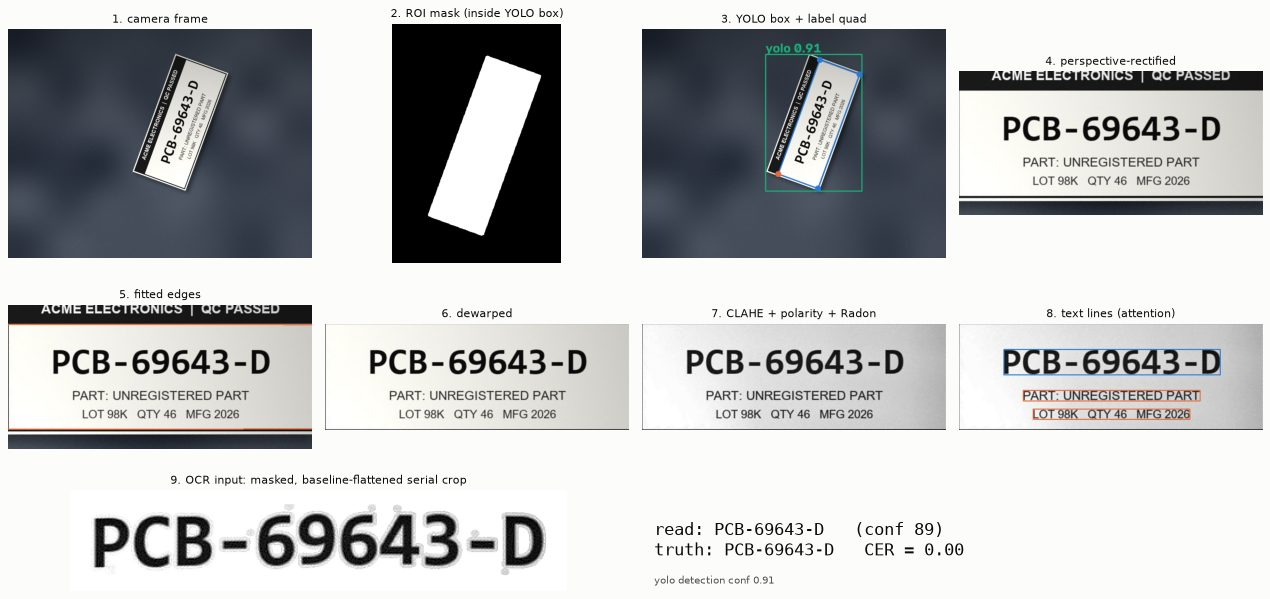

**perspective = 40, template `shipping`, rotation 57°**

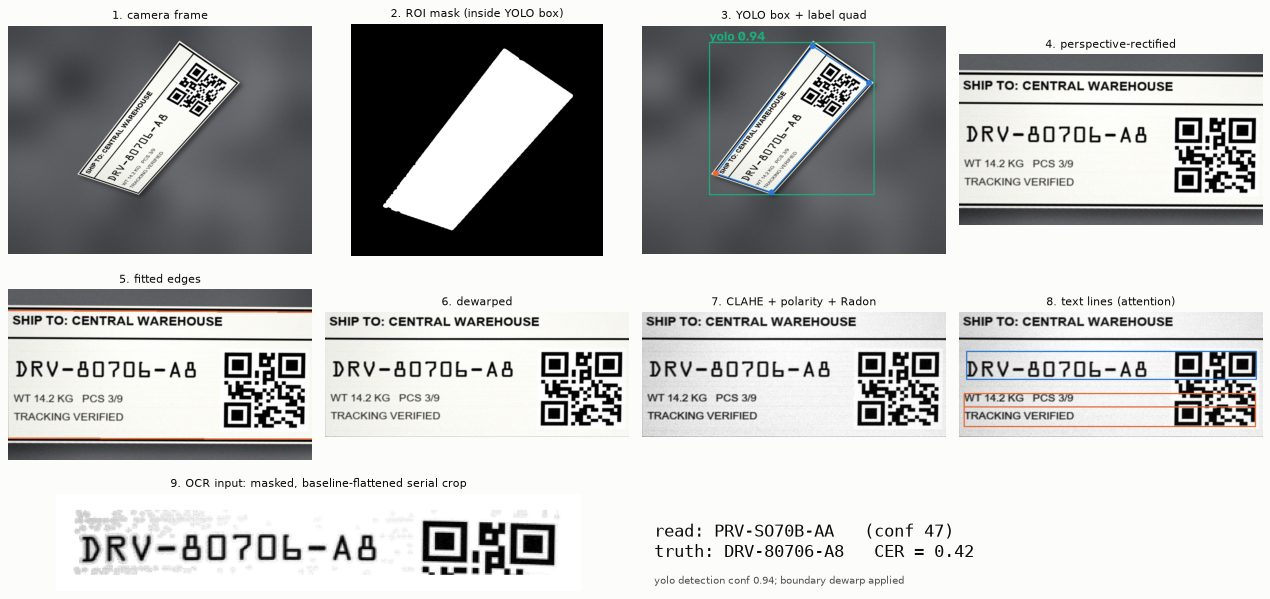

**curvature = 0.25, template `pcb`, rotation 79°**

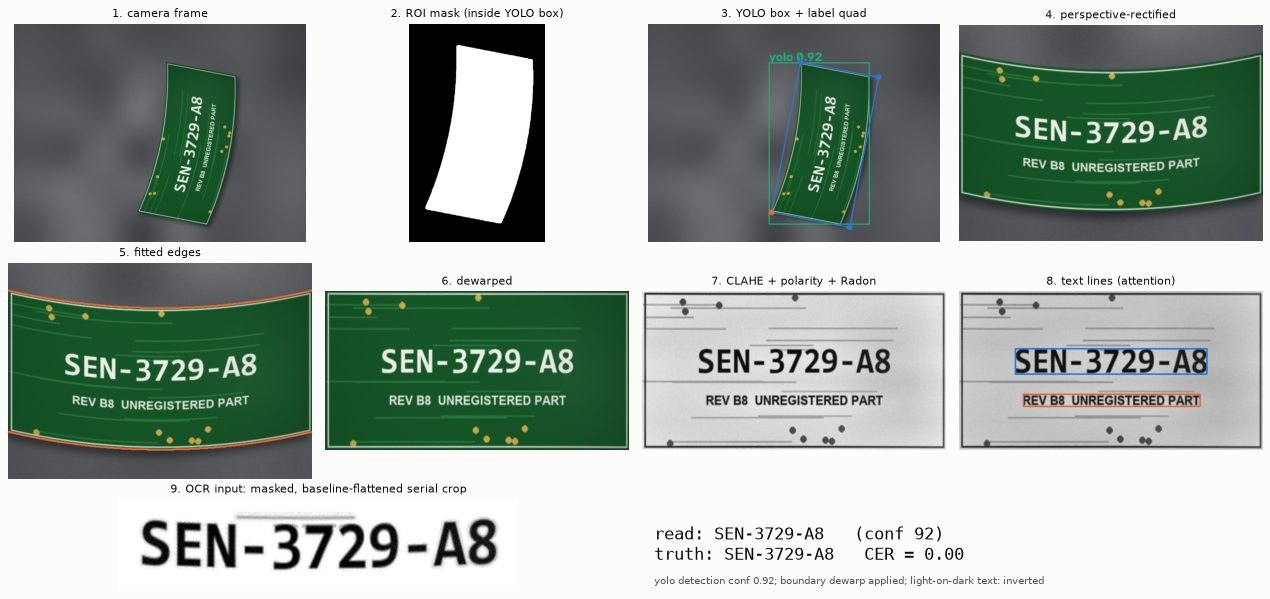

**crumple = 9, template `metal`, rotation 62°**

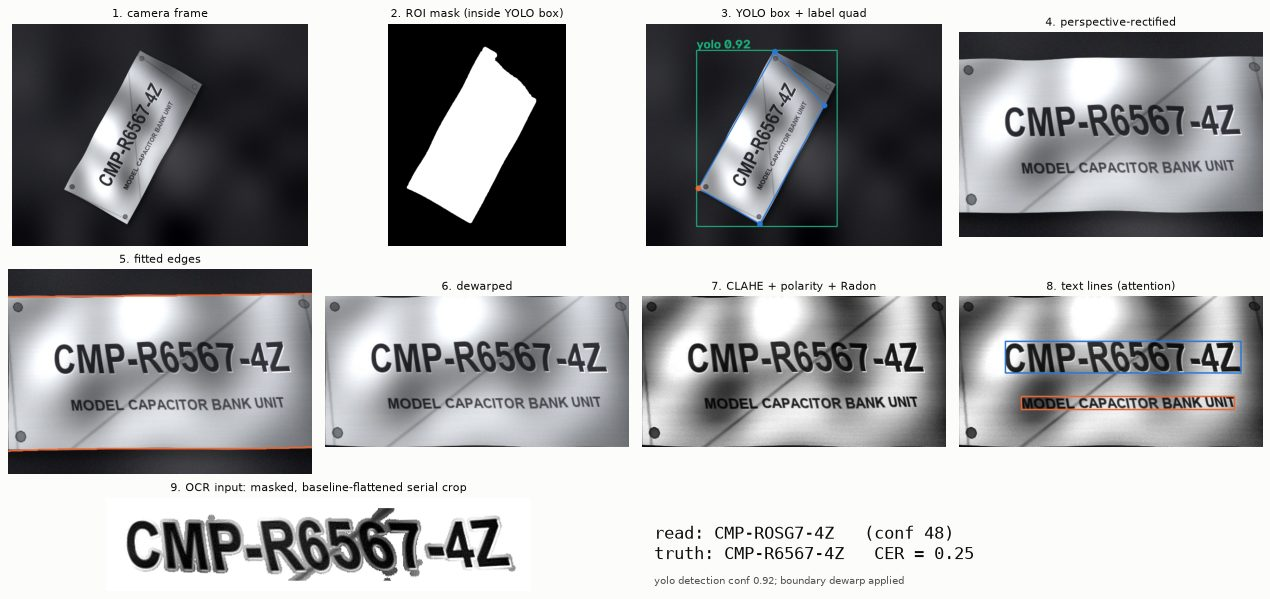

In [28]:
def stage_panel(img, gt=None, name="sample", engine=engine, save=True):
    r = read_label(img, engine, PipelineOptions(keep_stages=True))
    S = r.stages
    lines_key = "lines" if S.get("orientation", 0) == 0 else "lines_180"
    crops_key = "crops" if S.get("orientation", 0) == 0 else "crops_180"
    panels = [("1. camera frame", S.get("input")), ("2. ROI mask (inside YOLO box)", S.get("mask")),
              ("3. YOLO box + label quad", S.get("detection")), ("4. perspective-rectified", S.get("rectified")),
              ("5. fitted edges", S.get("edges", S.get("rectified"))), ("6. dewarped", S.get("dewarped")),
              ("7. CLAHE + polarity + Radon", S.get("enhanced")), ("8. text lines (attention)", S.get(lines_key))]
    panels = [(t, p) for t, p in panels if p is not None]
    crops = S.get(crops_key, [])
    fig = plt.figure(figsize=(16, 7.6))
    gs = fig.add_gridspec(3, 4, height_ratios=[1, 1, 0.42])
    for i, (t, p) in enumerate(panels[:8]):
        ax = fig.add_subplot(gs[i // 4, i % 4]); ax.axis("off")
        ax.imshow(p, cmap="gray" if p.ndim == 2 else None); ax.set_title(t, fontsize=10, fontweight="normal")
    ax = fig.add_subplot(gs[2, :2]); ax.axis("off")
    if crops:
        ax.imshow(crops[0], cmap="gray"); ax.set_title("9. OCR input: masked, baseline-flattened serial crop", fontsize=10, fontweight="normal")
    ax = fig.add_subplot(gs[2, 2:]); ax.axis("off")
    ok = gt is None or r.serial == gt
    txt = f"read: {r.serial}   (conf {r.conf:.0f})" + (f"\ntruth: {gt}   CER = {cer(gt, r.serial):.2f}" if gt else "")
    ax.text(0.02, 0.5, txt, fontsize=15, family="monospace", va="center", color=INK)
    ax.text(0.02, 0.05, "; ".join(r.notes), fontsize=9, color=INK2, va="bottom")
    plt.tight_layout()
    if save:
        plt.savefig(config.FIG_DIR / f"stages_{name}.png", dpi=130, bbox_inches="tight")
        for k, v in S.items():
            if isinstance(v, np.ndarray):
                cv2.imwrite(str(config.STAGE_DIR / f"{name}_{k}.png"), v if v.ndim == 2 else cv2.cvtColor(v, cv2.COLOR_RGB2BGR))
    show_photo_fig(fig)
    return r

examples = [("rotation", 70, "component"), ("perspective", 40, "shipping"), ("curvature", 0.25, "pcb"), ("crumple", 9, "metal")]
for split, level, tmpl in examples:
    sub = ann[(ann.split == split) & (np.isclose(ann.level.astype(float), level)) & (ann.template == tmpl)]
    row = (sub if len(sub) else ann[ann.split == split]).iloc[0]
    display(Markdown(f"**{split} = {level}, template `{row.template}`, rotation {row.angle:.0f}°**"))
    stage_panel(load_rgb(config.SYNTH_DIR / row.filename), row.serial, name=f"{split}_{row.template}")

## 7. Inventory verification & decision logic (verification layer)

`OCR text → normalisation → database lookup → validation → decision` (slide 8). Three decision states, each with one
physical output:

| Decision | When | Reason code (logged) | Output |
|---|---|---|---|
| **PASS** | serial found (≤ 2 OCR edits, unambiguous), lot OK, product as expected, QR (if any) agrees | `OK` | 🟢 green LED |
| **MISMATCH** | well-formed serial not in the inventory | `UNKNOWN_SERIAL` | 🔴 red LED |
| | serial found but the lot is flagged | `FAULTY_LOT` | 🔴 red LED |
| | serial is valid but belongs to a different product than this station/order expects | `WRONG_PRODUCT` | 🔴 red LED |
| | printed serial and QR code disagree (relabelled / tampered) | `QR_MISMATCH` | 🔴 red LED |
| **ERROR** | nothing readable, or the read fails the format check and matches nothing | `NO_READ` / `INCOMPLETE_READ` | 🔔 buzzer → re-capture |

The fuzzy match refuses to guess when two inventory serials are equally close, so a doubtful read becomes a MISMATCH or a
re-capture, never a wrong PASS. The QR code is an optional second identifier (pyzbar is rotation-invariant), listed as a
future improvement in the deck but already implemented here.

In [29]:
from pyzbar.pyzbar import decode as zbar_decode, ZBarSymbol

def read_qr(img):
    try:
        return [d.data.decode(errors="ignore") for d in zbar_decode(img, symbols=[ZBarSymbol.QRCODE])]
    except Exception:
        return []


def decide(read_serial, qr_values, db, expected_item=None):
    # Returns (decision, reason_code, matched_serial, edit_distance, human-readable reason)
    read_serial = read_serial or ""
    serial, dist = db.match(read_serial)
    qr_known = [q for q in qr_values if q in db.items.index]
    via_qr = False
    if serial is None and qr_known:
        serial, dist, via_qr = qr_known[0], 0, True
    if serial is None:
        if not read_serial and not qr_values:
            return "ERROR", "NO_READ", None, dist, "no text found: re-capture"
        if looks_like_serial(read_serial):
            return "MISMATCH", "UNKNOWN_SERIAL", None, dist, f"{read_serial} is not in the inventory (closest is {dist} edits away)"
        return "ERROR", "INCOMPLETE_READ", None, dist, f"unreadable / incomplete read {read_serial!r}: re-capture"
    if qr_values and serial not in qr_values and Levenshtein.distance(serial, qr_values[0]) > config.MAX_EDIT_DISTANCE:
        return "MISMATCH", "QR_MISMATCH", serial, dist, f"printed {serial} but QR says {qr_values[0]}"
    rec = db.items.loc[serial]
    if rec["status"] != "OK":
        return "MISMATCH", "FAULTY_LOT", serial, dist, f"lot flagged {rec['status']}"
    if expected_item and rec["item"] != expected_item:
        return "MISMATCH", "WRONG_PRODUCT", serial, dist, f"{serial} is a '{rec['item']}', station expects '{expected_item}'"
    how = "identified by QR (OCR unmatched)" if via_qr else ("exact match" if dist == 0 else f"matched within {dist} OCR edit(s)")
    return "PASS", "OK", serial, dist, how

## 8. Hardware integration (output layer)

The processing system decides, and the microcontroller only drives GPIO, so physical feedback stays real-time (slide 9).
One byte per inspection over USB serial:

| Byte | Decision | Arduino pin | Pico pin |
|---|---|---|---|
| `G` | PASS | green LED, D8 | GP15 |
| `R` | MISMATCH | red LED, D9 | GP14 |
| `E` | ERROR | buzzer, D10 (3 beeps) | GP13 |

The MCU answers `A` (ack), so the PC can confirm the indicator actually fired. `Indicator()` auto-detects an
Arduino/CH340/Pico port. With nothing plugged in it **simulates**, so the notebook runs anywhere. `MockSerial`
records the bytes for the system test in §10.4.

In [30]:
class MockSerial:
    # stands in for pyserial during testing: records every byte written and acknowledges like the firmware
    def __init__(self):
        self.sent = []
    def write(self, b):
        self.sent.append(b)
        return len(b)
    def read(self, n=1):
        return b"A"


class Indicator:
    CODES = {"PASS": b"G", "MISMATCH": b"R", "ERROR": b"E"}
    OUTPUT = {"PASS": "🟢 GREEN LED", "MISMATCH": "🔴 RED LED", "ERROR": "🔔 BUZZER (re-capture)"}

    def __init__(self, port=config.SERIAL_PORT, baud=config.SERIAL_BAUD, verbose=True, ser=None):
        self.ser, self.verbose = ser, verbose
        if ser is None:
            try:
                import serial, serial.tools.list_ports
                if not port:   # auto-detect an Arduino / CH340 / Pico style USB serial device
                    for p in serial.tools.list_ports.comports():
                        if any(k in (p.description or "") + (p.manufacturer or "") for k in ("Arduino", "CH340", "USB-SERIAL", "Pico", "MicroPython", "CP210")):
                            port = p.device; break
                if port:
                    self.ser = serial.Serial(port, baud, timeout=1)
                    time.sleep(2)  # Arduino resets on connect
                    print("Indicator connected on", port)
            except Exception as e:
                print("Indicator: hardware not available, simulating.", e if port else "")
        self.mode = "mock" if isinstance(self.ser, MockSerial) else ("hardware" if self.ser else "simulated")

    def signal(self, decision):
        code = self.CODES.get(decision, b"E")
        ack = None
        if self.ser:
            self.ser.write(code)
            ack = self.ser.read(1)
        if self.verbose:
            print(f"[{self.mode}] {self.OUTPUT.get(decision, 'BUZZER')}  ->  {decision}  (byte {code!r}{', ack ' + repr(ack) if ack else ''})")
        return code

indicator = Indicator()

In [31]:
ARDUINO = r"""
// Label verification station indicator (Review 2 output layer)
// Bytes from the PC:  G = PASS -> green LED   R = MISMATCH -> red LED   E = ERROR -> buzzer (re-capture)
const int GREEN = 8, RED = 9, BUZZ = 10;

void setup() {
  pinMode(GREEN, OUTPUT); pinMode(RED, OUTPUT); pinMode(BUZZ, OUTPUT);
  Serial.begin(9600);
  for (int i = 0; i < 2; i++) { digitalWrite(GREEN, HIGH); digitalWrite(RED, HIGH); delay(150);
                                digitalWrite(GREEN, LOW);  digitalWrite(RED, LOW);  delay(150); }
  Serial.println("READY");
}

void beep(int n, int onMs, int offMs) {
  for (int i = 0; i < n; i++) { digitalWrite(BUZZ, HIGH); delay(onMs); digitalWrite(BUZZ, LOW); delay(offMs); }
}

void loop() {
  if (!Serial.available()) return;
  char c = Serial.read();
  digitalWrite(GREEN, LOW); digitalWrite(RED, LOW);
  switch (c) {
    case 'G': digitalWrite(GREEN, HIGH); delay(1500); digitalWrite(GREEN, LOW); break;
    case 'R': digitalWrite(RED, HIGH);   delay(1500); digitalWrite(RED, LOW);   break;
    case 'E': beep(3, 120, 120); break;
  }
  Serial.write('A');   // ack
}
"""
PICO = r"""
# MicroPython for Raspberry Pi Pico: save as main.py. Same protocol as the Arduino sketch.
import sys, time
from machine import Pin
green, red, buzz = Pin(15, Pin.OUT), Pin(14, Pin.OUT), Pin(13, Pin.OUT)
def beep(n, on, off):
    for _ in range(n):
        buzz.on(); time.sleep_ms(on); buzz.off(); time.sleep_ms(off)
while True:
    c = sys.stdin.read(1)
    green.off(); red.off()
    if c == 'G':
        green.on(); time.sleep_ms(1500); green.off()
    elif c == 'R':
        red.on(); time.sleep_ms(1500); red.off()
    elif c == 'E':
        beep(3, 120, 120)
    sys.stdout.write('A')
"""
(config.HW_DIR / "indicator").mkdir(exist_ok=True)
(config.HW_DIR / "indicator" / "indicator.ino").write_text(ARDUINO.strip() + "\n")
(config.HW_DIR / "pico_main.py").write_text(PICO.strip() + "\n")
print("wrote", config.HW_DIR / "indicator" / "indicator.ino", "and", config.HW_DIR / "pico_main.py")

wrote E:\Wemby\label_verifier\hardware\indicator\indicator.ino and E:\Wemby\label_verifier\hardware\pico_main.py


## 9. Complete operating procedure (slide 10, all 12 steps)

`process_item()` is the station's main function. `trace=True` prints what each of the 12 steps produced for one item.

In [32]:
def process_item(img, engine=engine, db=db, indicator=None, source="notebook", log=True, opts=None,
                 expected_item=config.EXPECTED_ITEM, trace=False):
    say = print if trace else (lambda *a, **k: None)
    t0 = time.perf_counter()
    say(f" 1. product placed in the inspection area")
    say(f" 2. image captured: {img.shape[1]}x{img.shape[0]} px")
    bbox, dconf, src = detector.detect(resize_max(img))
    say(f" 3. target detected by {src}: box {tuple(int(v) for v in bbox) if bbox else None}, conf {dconf:.2f}")
    r = read_label(img, engine, opts or PipelineOptions())
    say(f" 4. ROI extracted ({'YOLO box + 12% margin' if src == 'yolo' else src})")
    say(f" 5. ROI preprocessed: {'; '.join(r.notes) or 'no corrections needed'}")
    say(f" 6. OCR read: {[t.text for t in r.tokens][:3]}")
    say(f" 7. normalised serial: {r.serial!r} (format check {'OK' if looks_like_serial(r.serial) else 'FAIL'}, conf {r.conf:.0f})")
    qr = read_qr(resize_max(img))
    decision, reason_code, serial, dist, reason = decide(r.serial, qr, db, expected_item)
    say(f" 8. inventory lookup: {serial or 'no match'} {('(' + str(dist) + ' edits)') if serial else ''}{' | QR ' + str(qr) if qr else ''}")
    say(f" 9. decision: {decision} [{reason_code}] {reason}")
    latency = round(1000 * (time.perf_counter() - t0))
    code = indicator.signal(decision) if indicator is not None else Indicator.CODES[decision]
    say(f"10. sent byte {code!r} to the microcontroller")
    say(f"11. indicator: {Indicator.OUTPUT[decision]}")
    if log:
        db.log_scan(source, r.serial, serial, dist, decision, reason_code, r.conf, ",".join(qr), latency)
    rec = db.items.loc[serial].to_dict() if serial else {}
    say(f"12. logged to the scans table ({latency} ms end-to-end)")
    return {"ocr_text": r.serial, "ocr_conf": round(r.conf, 1), "qr": qr, "matched_serial": serial, "edit_distance": dist,
            "decision": decision, "reason_code": reason_code, "reason": reason, "record": rec,
            "latency_ms": latency, "detector": src, "notes": r.notes}


row = ann[(ann.expected_decision == "PASS") & (ann.split == "mixed")].iloc[0]
print(f"=== item: {row.filename}  (truth {row.serial}, {row.template}, rotation {row.angle:.0f}°, tilt {row.tilt:.0f}°)")
out = process_item(load_rgb(config.SYNTH_DIR / row.filename), indicator=indicator, source="demo", trace=True)

=== item: images/mixed_0341.jpg  (truth CMP-R6567-4Z, metal, rotation 42°, tilt 27°)
 1. product placed in the inspection area
 2. image captured: 1280x960 px
 3. target detected by yolo: box (308, 255, 863, 818), conf 0.95


 4. ROI extracted (YOLO box + 12% margin)
 5. ROI preprocessed: yolo detection conf 0.95; boundary dewarp applied
 6. OCR read: ['CMP-R6567-42:', 'MODEL CAPACITOR BANK UNIT']
 7. normalised serial: 'CMP-R6567-42' (format check OK, conf 45)
 8. inventory lookup: CMP-R6567-4Z (1 edits)
 9. decision: PASS [OK] matched within 1 OCR edit(s)
[simulated] 🟢 GREEN LED  ->  PASS  (byte b'G')
10. sent byte b'G' to the microcontroller
11. indicator: 🟢 GREEN LED
12. logged to the scans table (1356 ms end-to-end)


In [33]:
# one item of every outcome, including a wrong-product scan at a station configured for a different product
demo = [(ann[(ann.expected_reason == "OK") & (ann.split == "mixed")].iloc[1], None),
        (ann[(ann.expected_reason == "FAULTY_LOT")].iloc[0], None),
        (ann[(ann.expected_reason == "UNKNOWN_SERIAL") & (ann.split == "mixed")].iloc[0], None),
        (ann[(ann.expected_reason == "OK") & (ann.split == "mixed")].iloc[2], "Shipping Carton")]
for row, expect in demo:
    img = load_rgb(config.SYNTH_DIR / row.filename)
    o = process_item(img, indicator=indicator, source="demo", expected_item=expect)
    print(f"truth {row.serial:14} ({row.expected_reason:14}) station expects {str(expect):16} -> {o['decision']:8} "
          f"[{o['reason_code']}] {o['reason']}")
print()
db.recent_scans(6)

[simulated] 🟢 GREEN LED  ->  PASS  (byte b'G')
truth PSU-R677-HG    (OK            ) station expects None             -> PASS     [OK] matched within 2 OCR edit(s)


[simulated] 🔴 RED LED  ->  MISMATCH  (byte b'R')
truth SN-9493-U      (FAULTY_LOT    ) station expects None             -> MISMATCH [FAULTY_LOT] lot flagged FAULTY


[simulated] 🔴 RED LED  ->  MISMATCH  (byte b'R')
truth SN-052191-83   (UNKNOWN_SERIAL) station expects None             -> MISMATCH [UNKNOWN_SERIAL] SN-052191-83 is not in the inventory (closest is 6 edits away)


[simulated] 🔴 RED LED  ->  MISMATCH  (byte b'R')
truth DRV-82662-L2   (OK            ) station expects Shipping Carton  -> MISMATCH [WRONG_PRODUCT] DRV-82662-L2 is a 'Stepper Driver Board', station expects 'Shipping Carton'



,id,ts,source,ocr_text,matched_serial,edit_distance,decision,reason,conf,qr,latency_ms
0,45,2026-10-03 18:48:40,demo,DRV-82662-L2,DRV-82662-L2,0,MISMATCH,WRONG_PRODUCT,91.0,,401
1,44,2026-10-03 18:48:39,demo,SN-052191-83,NaN,6,MISMATCH,UNKNOWN_SERIAL,36.0,,1262
2,43,2026-10-03 18:48:38,demo,SN-9493-U,SN-9493-U,0,MISMATCH,FAULTY_LOT,90.0,,385
3,42,2026-10-03 18:48:38,demo,PSU-RB7-HG,PSU-R677-HG,2,PASS,OK,45.0,PSU-R677-HG,2026
4,41,2026-10-03 18:48:36,demo,CMP-R6567-42,CMP-R6567-4Z,1,PASS,OK,45.0,,1356
5,40,2026-10-03 18:43:55,demo,DRV-82662-L2,DRV-82662-L2,0,MISMATCH,WRONG_PRODUCT,91.0,,442


## 10. Testing & evaluation (slide 12)

| Slide 12 test | What is measured here | Section |
|---|---|---|
| **Detection testing**: correct localisation, missed / incorrect detections | IoU of the YOLO box vs ground truth, detection rate at IoU ≥ 0.5, misses, plus corner error of the geometric quad | 10.1 |
| **OCR testing**: correct serial recognition; substitutions, omissions, extra characters | exact-read rate, CER vs rotation / tilt / bend / crumple, edit-operation breakdown, most-confused characters | 10.2 |
| **Verification testing**: valid, invalid/unknown serial, incorrect product mapping | rule-by-rule unit tests, plus the product-mapping test on every PASS image | 10.3 |
| **System testing**: response time, correct PASS/MISMATCH output, correct LED/buzzer response | end-to-end latency, decision confusion matrix, byte-level indicator check | 10.4 |

Then: 10.5 ablation (what each preprocessing stage contributes), 10.6 a second OCR engine.
The same code runs on real photos (§11).

### 10.1 Detection testing

,detection rate (IoU≥0.5),mean IoU,missed (no box),incorrect (0<IoU<0.5),median ms/frame
detector,,,,,
yolo,100.0%,0.960,0,0,102
classical,99.8%,0.903,0,1,23


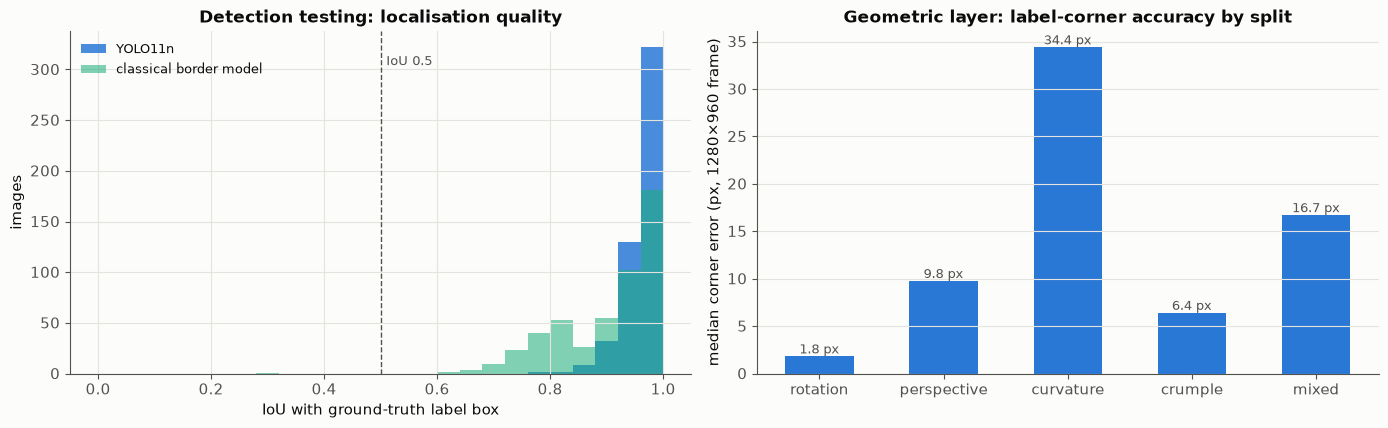

In [34]:
det_path = config.RESULT_DIR / "detection_results.csv"
if RERUN_EVALUATION or not det_path.exists():
    classical = LabelDetector(None)
    def det_job(item):
        _, row = item
        img = load_rgb(config.SYNTH_DIR / row.filename)
        gt_c = np.array(parse_corners(row.corners), np.float32)
        gt = corners_to_bbox(gt_c)
        out = {"filename": row.filename}
        for name, d in (("yolo", detector), ("classical", classical)):
            t0 = time.perf_counter()
            box, conf, src = d.detect(img)
            out[f"{name}_ms"] = 1000 * (time.perf_counter() - t0)
            out[f"{name}_src"] = src
            out[f"{name}_iou"] = bbox_iou(box, gt) if box else 0.0
        # geometric layer: corner error of the fitted quad (best of the 4 cyclic orderings and their reverse)
        g = locate(img)
        if g.found:
            q = g.quad.astype(np.float32)
            errs = [np.linalg.norm(np.roll(qq, k, 0) - gt_c, axis=1).mean() for qq in (q, q[::-1]) for k in range(4)]
            out["corner_err_px"] = float(min(errs))
        else:
            out["corner_err_px"] = np.nan
        return out
    with ThreadPoolExecutor(WORKERS) as ex:
        det = pd.DataFrame(list(ex.map(det_job, ann.iterrows()))).merge(ann, on="filename")
    det.to_csv(det_path, index=False)
else:
    det = pd.read_csv(det_path)

# latency is timed sequentially on 30 frames (inside the parallel run, threads queue on the shared YOLO model)
speed = {"yolo": [], "classical": []}
for row in ann.sample(30, random_state=5).itertuples():
    img = load_rgb(config.SYNTH_DIR / row.filename)
    for name, d in (("yolo", detector), ("classical", LabelDetector(None))):
        t0 = time.perf_counter(); d.detect(img); speed[name].append(1000 * (time.perf_counter() - t0))

rows = []
for name in ("yolo", "classical"):
    iou = det[f"{name}_iou"]
    rows.append({"detector": name if name == "classical" or detector.name == "yolo" else "yolo (not trained → classical)",
                 "detection rate (IoU≥0.5)": (iou >= 0.5).mean(), "mean IoU": iou.mean(),
                 "missed (no box)": int((iou == 0).sum()), "incorrect (0<IoU<0.5)": int(((iou > 0) & (iou < 0.5)).sum()),
                 "median ms/frame": np.median(speed[name])})
display(pd.DataFrame(rows).set_index("detector").style.format({"detection rate (IoU≥0.5)": "{:.1%}", "mean IoU": "{:.3f}", "median ms/frame": "{:.0f}"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
bins = np.linspace(0, 1, 26)
axes[0].hist(det.yolo_iou, bins=bins, color=C["pipeline"], alpha=0.85, label="YOLO11n")
axes[0].hist(det.classical_iou, bins=bins, color=C["rotation_only"], alpha=0.55, label="classical border model")
axes[0].axvline(0.5, color=INK2, lw=1, ls="--"); axes[0].text(0.51, axes[0].get_ylim()[1] * 0.9, "IoU 0.5", color=INK2, fontsize=9)
axes[0].set_xlabel("IoU with ground-truth label box"); axes[0].set_ylabel("images"); axes[0].legend(fontsize=9, loc="upper left")
axes[0].set_title("Detection testing: localisation quality")
ce = det.groupby("split").corner_err_px.median().reindex(["rotation", "perspective", "curvature", "crumple", "mixed"])
axes[1].bar(ce.index, ce.values, color=C["pipeline"], width=0.55)
for i, v in enumerate(ce.values):
    axes[1].text(i, v + 0.3, f"{v:.1f} px", ha="center", fontsize=9, color=INK2)
axes[1].set_ylabel("median corner error (px, 1280×960 frame)"); axes[1].grid(axis="x", visible=False)
axes[1].set_title("Geometric layer: label-corner accuracy by split")
plt.tight_layout(); plt.savefig(config.FIG_DIR / "detection_testing.png", dpi=160, bbox_inches="tight"); plt.show()

### 10.2 OCR testing: whole dataset, three readers

`evaluate()` runs any set of readers over any dataset folder with an `annotations.csv` (synthetic **or real**) and records,
per image and method: predicted serial, **CER**, exact match, confidence, latency and the verification decision.
The pipeline reader includes YOLO detection. Results are cached in `outputs/results/`.

In [35]:
READERS = {
    "baseline": read_baseline,
    "rotation_only": read_rotation_only,
    "pipeline": lambda img, eng: read_label(img, eng, detector=detector),
}

def evaluate(ann_df, base_dir, readers=READERS, engine=engine, workers=WORKERS, db=db, desc=""):
    def job(item):
        _, row = item
        img = load_rgb(Path(base_dir) / row["filename"])
        qr = read_qr(resize_max(img))
        out = []
        for name, fn in readers.items():
            t0 = time.perf_counter()
            err = ""
            try:
                r = fn(img, engine)
                pred, conf = r.serial, r.conf
            except Exception as e:     # one bad image must never stop the run, but we record why
                pred, conf, r, err = "", 0.0, None, f"{type(e).__name__}: {e}"
            dt = time.perf_counter() - t0
            dec, why = decide(pred, [], db)[:2]  # OCR-only decision (no QR help)
            o = {"filename": row["filename"], "method": name, "pred": pred, "conf": conf, "latency_s": dt,
                 "decision": dec, "reason_code": why, "qr_found": bool(qr), "error": err}
            if "serial" in row and isinstance(row["serial"], str):
                o["cer"] = cer(row["serial"], pred)
                o["exact"] = pred == row["serial"]
            out.append(o)
        return out
    t0 = time.time()
    if workers <= 1:   # torch-based engines (EasyOCR/Paddle) run in the main thread
        res = [o for item in ann_df.iterrows() for o in job(item)]
    else:
        with ThreadPoolExecutor(workers) as ex:
            res = [o for lst in ex.map(job, ann_df.iterrows()) for o in lst]
    n_err = sum(1 for o in res if o["error"])
    if n_err:
        print(f"WARNING: {n_err} reads raised an exception, e.g. {next(o['error'] for o in res if o['error'])}")
    print(f"{desc} evaluated {len(ann_df)} images x {len(readers)} methods in {time.time() - t0:.0f}s")
    df = pd.DataFrame(res).merge(ann_df, on="filename", how="left")
    if "expected_decision" in df:
        df["decision_correct"] = df.decision == df.expected_decision
        if "expected_reason" in df:
            df["reason_correct"] = df.decision_correct & ((df.decision == "PASS") | (df.reason_code == df.expected_reason))
    return df

res_path = config.RESULT_DIR / "synthetic_results.csv"
if RERUN_EVALUATION or not res_path.exists():
    results = evaluate(ann, config.SYNTH_DIR, desc="synthetic:")
    results.to_csv(res_path, index=False)
else:
    results = pd.read_csv(res_path)
    print("Loaded cached results:", res_path)

summary = (results.groupby("method")
           .agg(CER=("cer", "mean"), exact_match=("exact", "mean"), decision_acc=("decision_correct", "mean"),
                median_latency_ms=("latency_s", lambda s: 1000 * s.median()))
           .reindex(list(READERS)))
display(summary.style.format({"CER": "{:.3f}", "exact_match": "{:.1%}", "decision_acc": "{:.1%}", "median_latency_ms": "{:.0f}"}))

Loaded cached results: E:\Wemby\label_verifier\outputs\results\synthetic_results.csv


,CER,exact_match,decision_acc,median_latency_ms
method,,,,
baseline,0.908,3.0%,4.8%,467
rotation_only,0.352,42.5%,58.7%,497
pipeline,0.070,70.6%,91.9%,876


#### The headline graph: CER vs rotation angle

Mean CER per angle, with a shaded 95 % confidence interval (12 images per angle, all four templates).
The second panel shows the same data as the exact serial read rate, which is what decides green vs red at the station.

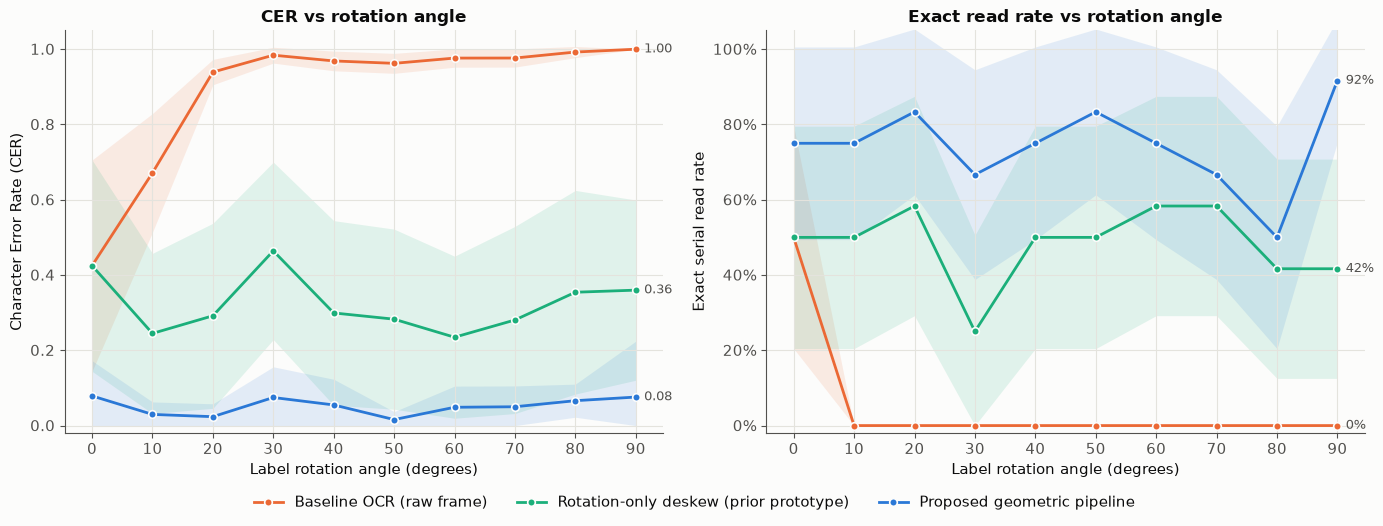

angle,0.0,10.0,20.0,30.0,40.0,50.0,60.0,70.0,80.0,90.0
method,,,,,,,,,,
baseline,0.425,0.671,0.939,0.984,0.969,0.962,0.976,0.977,0.992,1.000
rotation_only,0.425,0.245,0.292,0.464,0.299,0.283,0.235,0.281,0.354,0.360
pipeline,0.079,0.030,0.024,0.075,0.055,0.016,0.049,0.050,0.066,0.076


In [36]:
def ci95(s):
    s = s.dropna()
    return 1.96 * s.std(ddof=1) / math.sqrt(len(s)) if len(s) > 1 else 0.0

def sweep_plot(ax, split, param, xlabel, metric="cer", ylabel="Character Error Rate (CER)", label_ends=True):
    sub = results[results.split == split]
    for m in READERS:
        g = sub[sub.method == m].groupby("level")[metric]
        mean, err = g.mean(), g.apply(ci95)
        x = mean.index.astype(float)
        ax.fill_between(x, (mean - err).clip(lower=0), (mean + err), color=C[m], alpha=0.12, lw=0)
        ax.plot(x, mean.values, color=C[m], marker="o", ms=5.5, label=LABEL[m], markeredgecolor=SURFACE, markeredgewidth=1.2)
        if label_ends:
            ax.annotate(f"{mean.values[-1]:.2f}" if metric == "cer" else f"{mean.values[-1]:.0%}",
                        (x[-1], mean.values[-1]), xytext=(6, 0), textcoords="offset points", va="center", fontsize=9, color=INK2)
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_ylim(-0.02, 1.05)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sweep_plot(axes[0], "rotation", "angle", "Label rotation angle (degrees)")
axes[0].set_title("CER vs rotation angle")
axes[0].set_xticks(range(0, 91, 10))
sweep_plot(axes[1], "rotation", "angle", "Label rotation angle (degrees)", metric="exact", ylabel="Exact serial read rate")
axes[1].set_title("Exact read rate vs rotation angle"); axes[1].set_xticks(range(0, 91, 10))
axes[1].yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout(); plt.savefig(config.FIG_DIR / "cer_vs_rotation.png", dpi=160, bbox_inches="tight"); plt.show()

tbl = results[results.split == "rotation"].pivot_table(index="level", columns="method", values="cer", aggfunc="mean")[list(READERS)]
tbl.index.name = "angle"; tbl.round(3).T

#### CER vs the other distortions

Each sweep varies one factor. Rotation is randomised (0–90°) in all of them, which is why the baseline is already poor at
level 0. The point is how the pipeline holds up as tilt, bending and crumpling get worse.

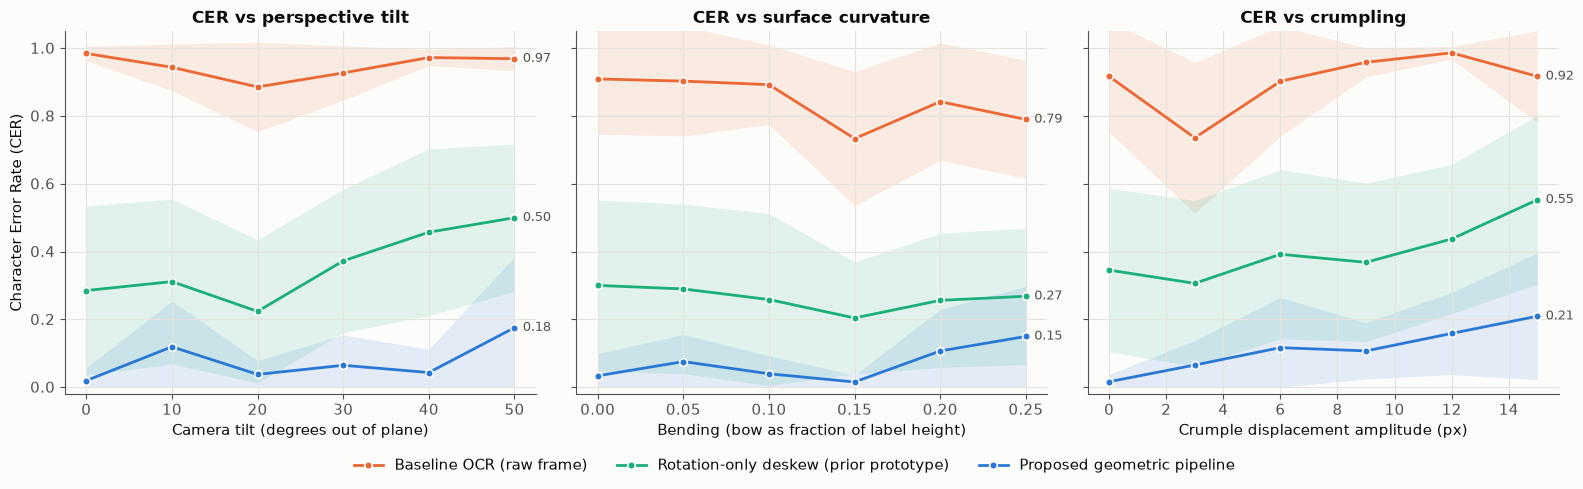

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), sharey=True)
sweep_plot(axes[0], "perspective", "tilt", "Camera tilt (degrees out of plane)"); axes[0].set_title("CER vs perspective tilt")
sweep_plot(axes[1], "curvature", "bend", "Bending (bow as fraction of label height)"); axes[1].set_title("CER vs surface curvature")
sweep_plot(axes[2], "crumple", "crumple", "Crumple displacement amplitude (px)"); axes[2].set_title("CER vs crumpling")
for ax in axes[1:]:
    ax.set_ylabel("")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.07))
plt.tight_layout(); plt.savefig(config.FIG_DIR / "cer_vs_distortions.png", dpi=160, bbox_inches="tight"); plt.show()

#### Character-level error types (slide 12: substitutions, omissions, extra characters)

`Levenshtein.editops(truth, read)` splits every error into a **substitution** (wrong character), an **omission** (a true
character missing from the read) or an **extra character**, normalised per 100 ground-truth characters.

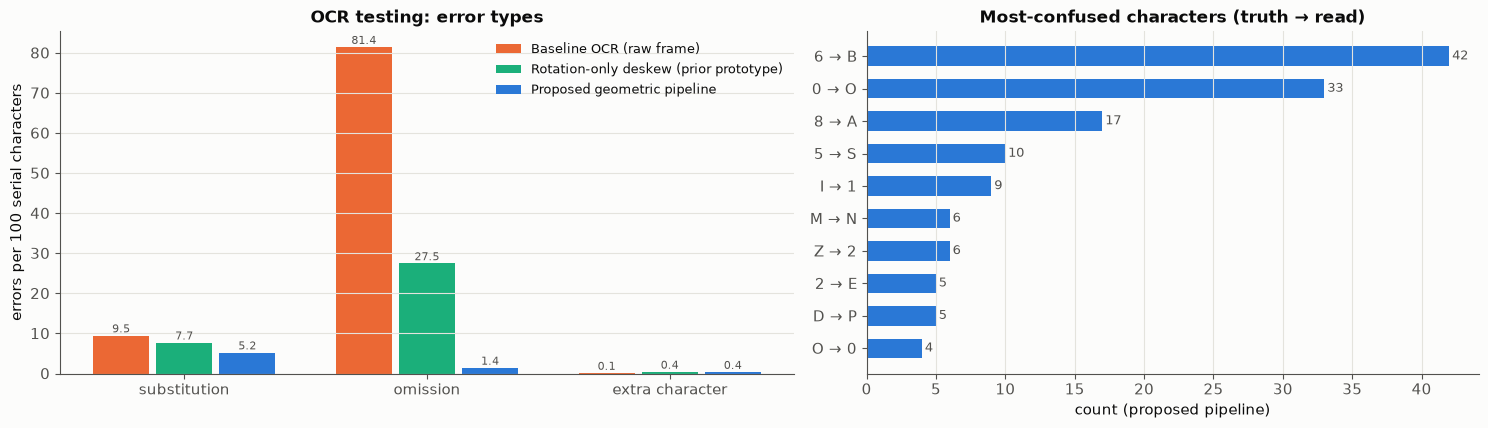

,substitution,omission,extra character
method,,,
baseline,9.48,81.43,0.12
rotation_only,7.70,27.48,0.41
pipeline,5.23,1.41,0.36


In [38]:
def edit_breakdown(df):
    out = []
    for m, sub in df.groupby("method"):
        n = sub.serial.str.len().sum()
        cnt = {"substitution": 0, "omission": 0, "extra character": 0}
        for gt, pred in zip(sub.serial, sub.pred.fillna("")):
            for op, _, _ in Levenshtein.editops(gt, pred):
                cnt[{"replace": "substitution", "delete": "omission", "insert": "extra character"}[op]] += 1
        out.append({"method": m, **{k: 100 * v / n for k, v in cnt.items()}})
    return pd.DataFrame(out).set_index("method").reindex(list(READERS))

eb = edit_breakdown(results)
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.2, 1]})
x = np.arange(3); w = 0.26
for i, m in enumerate(READERS):
    bars = axes[0].bar(x + (i - 1) * w, eb.loc[m].values, w - 0.03, color=C[m], label=LABEL[m])
    for b, v in zip(bars, eb.loc[m].values):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.8, f"{v:.1f}", ha="center", fontsize=8, color=INK2)
axes[0].set_xticks(x, eb.columns); axes[0].set_ylabel("errors per 100 serial characters")
axes[0].set_title("OCR testing: error types"); axes[0].legend(fontsize=9, loc="upper right"); axes[0].grid(axis="x", visible=False)

pipe = results[results.method == "pipeline"]
pairs = {}
for gt, pred in zip(pipe.serial, pipe.pred.fillna("")):
    for op, i, j in Levenshtein.editops(gt, pred):
        if op == "replace":
            pairs[f"{gt[i]} → {pred[j]}"] = pairs.get(f"{gt[i]} → {pred[j]}", 0) + 1
top = pd.Series(pairs).sort_values(ascending=False).head(10)[::-1]
axes[1].barh(top.index, top.values, color=C["pipeline"], height=0.6)
for i, v in enumerate(top.values):
    axes[1].text(v + 0.2, i, str(v), va="center", fontsize=9, color=INK2)
axes[1].set_xlabel("count (proposed pipeline)"); axes[1].set_title("Most-confused characters (truth → read)"); axes[1].grid(axis="y", visible=False)
plt.tight_layout(); plt.savefig(config.FIG_DIR / "ocr_error_types.png", dpi=160, bbox_inches="tight"); plt.show()
display(eb.round(2))

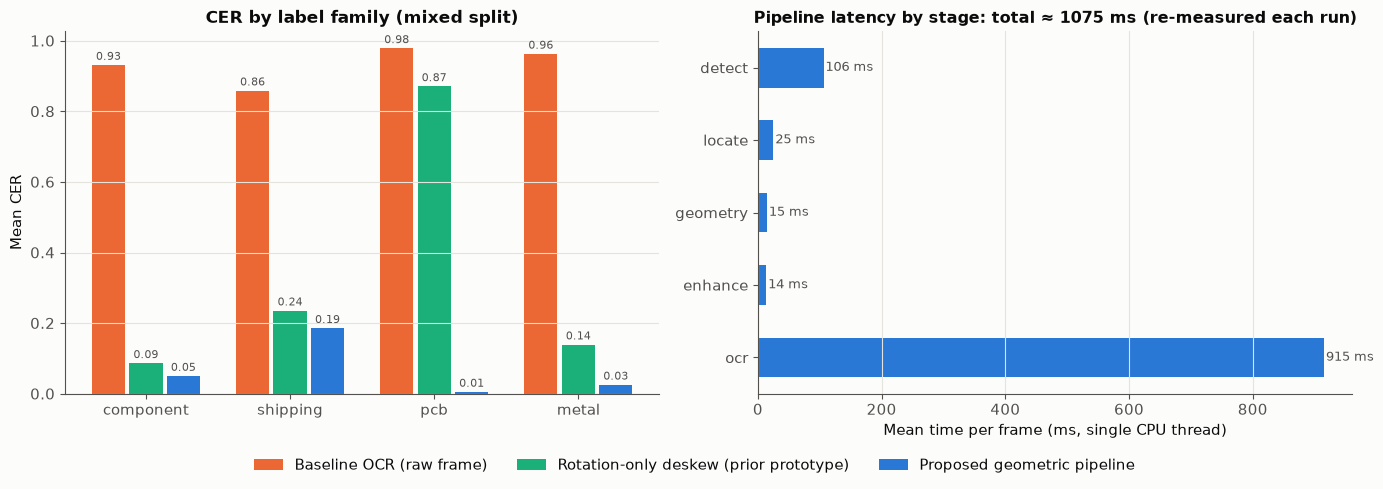

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
# per-template CER on the realistic 'mixed' split
mixed = results[results.split == "mixed"]
pt = mixed.pivot_table(index="template", columns="method", values="cer", aggfunc="mean")[list(READERS)].reindex(list(TEMPLATES))
x = np.arange(len(pt)); w = 0.26
for i, m in enumerate(READERS):
    bars = axes[0].bar(x + (i - 1) * w, pt[m].values, w - 0.03, color=C[m], label=LABEL[m])
    for b, v in zip(bars, pt[m].values):
        axes[0].text(b.get_x() + b.get_width() / 2, v + 0.015, f"{v:.2f}", ha="center", fontsize=8, color=INK2)
axes[0].set_xticks(x, pt.index); axes[0].set_ylabel("Mean CER"); axes[0].set_title("CER by label family (mixed split)")
axes[0].grid(axis="x", visible=False)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.07))

# latency of the proposed pipeline per stage (edge feasibility)
sample = ann[ann.split == "mixed"].sample(24, random_state=1)  # stage timing, YOLO included
stage_t = []
for _, row in sample.iterrows():
    r = read_label(load_rgb(config.SYNTH_DIR / row.filename), engine, detector=detector)
    stage_t.append(r.timings)
st = pd.DataFrame(stage_t).fillna(0).mean() * 1000
axes[1].barh(st.index[::-1], st.values[::-1], color=C["pipeline"], height=0.55)
for i, v in enumerate(st.values[::-1]):
    axes[1].text(v + 3, i, f"{v:.0f} ms", va="center", fontsize=9, color=INK2)
axes[1].set_xlabel("Mean time per frame (ms, single CPU thread)"); axes[1].grid(axis="y", visible=False)
axes[1].set_title(f"Pipeline latency by stage: total ≈ {st.sum():.0f} ms (re-measured each run)", fontsize=11.5)
plt.tight_layout(); plt.savefig(config.FIG_DIR / "per_template_and_latency.png", dpi=160, bbox_inches="tight"); plt.show()

### 10.3 Verification testing

Rule-by-rule unit tests of `decide()`, covering the three cases slide 12 lists (valid serial, invalid/unknown serial,
incorrect product mapping) plus the edge cases. Then the **product-mapping test** at dataset scale: every PASS image's
OCR result is re-verified with the station set to the right product (should PASS) and to a wrong product (should MISMATCH).

In [40]:
good = db.items[db.items.status == "OK"].iloc[0]
bad = db.items[db.items.status != "OK"].iloc[0]
other_item = db.items[db.items.item != good["item"]].item.iloc[0]
s = good.name
one_off = s[:-1] + ("X" if s[-1] != "X" else "Y")
cases = [
    ("valid serial",                       s,             [],          None,          "PASS"),
    ("valid serial, 1 OCR substitution",   one_off,       [],          None,          "PASS"),
    ("valid serial, correct product",      s,             [],          good["item"],  "PASS"),
    ("incorrect product mapping",          s,             [],          other_item,    "MISMATCH"),
    ("unknown, well-formed serial",        "ZZZ-999999-Q", [],         None,          "MISMATCH"),
    ("faulty / recalled lot",              bad.name,      [],          None,          "MISMATCH"),
    ("printed serial ≠ QR code",           s,             ["BOX-000001-Q"], None,     "MISMATCH"),
    ("OCR failed, QR identifies item",     "",            [s],         None,          "PASS"),
    ("nothing readable",                   "",            [],          None,          "ERROR"),
    ("incomplete / garbled read",          "7~X",         [],          None,          "ERROR"),
]
rows = []
for name, text, qr, expect_item, expected in cases:
    d, why, serial, dist, reason = decide(text, qr, db, expect_item)
    rows.append({"test case": name, "OCR text": text, "QR": ",".join(qr), "station expects": expect_item or "-",
                 "expected": expected, "got": d, "reason code": why, "result": "✅" if d == expected else "❌"})
vt = pd.DataFrame(rows)
display(vt)
print(f"{(vt.result == '✅').sum()}/{len(vt)} verification rules behave as specified")

# product-mapping test on every true-PASS image, re-using the cached pipeline reads (no new OCR)
p = results[(results.method == "pipeline") & (results.expected_decision == "PASS")]
items = db.items["item"]
right = [decide(pr, [], db, items.get(gt))[0] for pr, gt in zip(p.pred.fillna(""), p.serial)]
wrong = [decide(pr, [], db, next(i for i in items.unique() if i != items.get(gt)))[0] for pr, gt in zip(p.pred.fillna(""), p.serial)]
print(f"Station set to the RIGHT product: {np.mean(np.array(right) == 'PASS'):.1%} PASS "
      f"(the rest are OCR misses -> MISMATCH/ERROR)")
print(f"Station set to a WRONG product:   {np.mean(np.array(wrong) != 'PASS'):.1%} correctly rejected (never a green light)")

,test case,OCR text,QR,station expects,expected,got,reason code,result
0,valid serial,CTL-Y45515-D,,-,PASS,PASS,OK,✅
1,"valid serial, 1 OCR substitution",CTL-Y45515-X,,-,PASS,PASS,OK,✅
2,"valid serial, correct product",CTL-Y45515-D,,Motor Controller,PASS,PASS,OK,✅
3,incorrect product mapping,CTL-Y45515-D,,Return Label Stock,MISMATCH,MISMATCH,WRONG_PRODUCT,✅
4,"unknown, well-formed serial",ZZZ-999999-Q,,-,MISMATCH,MISMATCH,UNKNOWN_SERIAL,✅
5,faulty / recalled lot,SN-9493-U,,-,MISMATCH,MISMATCH,FAULTY_LOT,✅
6,printed serial ≠ QR code,CTL-Y45515-D,BOX-000001-Q,-,MISMATCH,MISMATCH,QR_MISMATCH,✅
7,"OCR failed, QR identifies item",,CTL-Y45515-D,-,PASS,PASS,OK,✅
8,nothing readable,,,-,ERROR,ERROR,NO_READ,✅
9,incomplete / garbled read,7~X,,-,ERROR,ERROR,INCOMPLETE_READ,✅


10/10 verification rules behave as specified
Station set to the RIGHT product: 89.9% PASS (the rest are OCR misses -> MISMATCH/ERROR)
Station set to a WRONG product:   100.0% correctly rejected (never a green light)


### 10.4 System testing: response time, decision correctness, LED/buzzer response

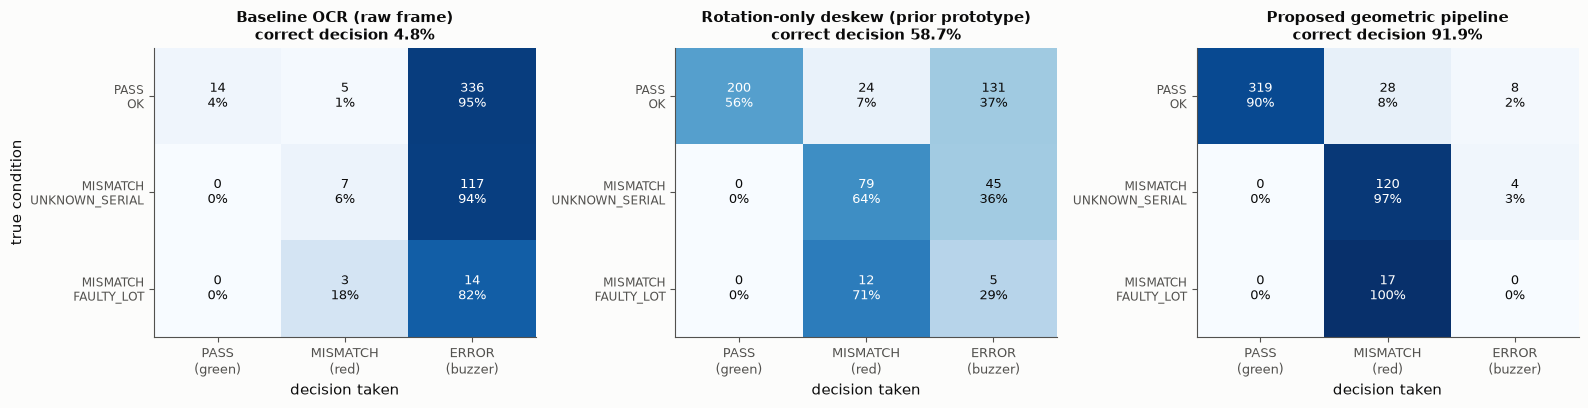

False PASS (unknown/faulty part given a green light): {'baseline': 0, 'rotation_only': 0, 'pipeline': 0}
Good parts sent to re-capture (ERROR): {'baseline': '94.6%', 'rotation_only': '36.9%', 'pipeline': '2.3%'}


In [41]:
# decision confusion matrix: true condition (with reason) vs decision taken, OCR only (no QR help)
rows_order = [("PASS", "OK"), ("MISMATCH", "UNKNOWN_SERIAL"), ("MISMATCH", "FAULTY_LOT")]
cols = ["PASS", "MISMATCH", "ERROR"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, m in zip(axes, READERS):
    sub = results[results.method == m]
    cm = np.array([[((sub.expected_reason == r) & (sub.decision == c)).sum() for c in cols] for _, r in rows_order])
    norm = cm / cm.sum(1, keepdims=True)
    ax.imshow(norm, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}\n{norm[i, j]:.0%}", ha="center", va="center", fontsize=9,
                    color="white" if norm[i, j] > 0.55 else INK)
    ax.set_xticks(range(3), ["PASS\n(green)", "MISMATCH\n(red)", "ERROR\n(buzzer)"], fontsize=9)
    ax.set_yticks(range(3), [f"{d}\n{r}" for d, r in rows_order], fontsize=8.5); ax.grid(False)
    ax.set_title(f"{LABEL[m]}\ncorrect decision {sub.decision_correct.mean():.1%}", fontsize=10.5)
    ax.set_xlabel("decision taken")
axes[0].set_ylabel("true condition")
plt.tight_layout(); plt.savefig(config.FIG_DIR / "decision_confusion.png", dpi=160, bbox_inches="tight"); plt.show()

fp = results[(results.expected_decision != "PASS") & (results.decision == "PASS")].groupby("method").size().reindex(list(READERS), fill_value=0)
rc = results[results.expected_decision == "PASS"].groupby("method").decision.apply(lambda s: (s == "ERROR").mean()).reindex(list(READERS))
print("False PASS (unknown/faulty part given a green light):", fp.to_dict())
print("Good parts sent to re-capture (ERROR):", {k: f"{v:.1%}" for k, v in rc.items()})

Indicator byte matches the decision for 100% of 40 items (bytes sent: {'G': np.int64(28), 'R': np.int64(12)})


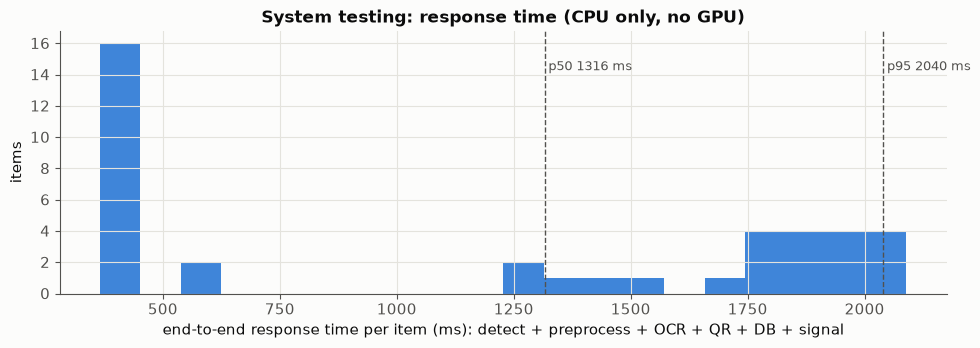

In [42]:
# end-to-end response time + LED/buzzer byte check through a mock serial port
mock = MockSerial()
test_ind = Indicator(ser=mock, verbose=False)
sample = ann.sample(40, random_state=11)
lat, ok = [], []
for row in sample.itertuples():
    o = process_item(load_rgb(config.SYNTH_DIR / row.filename), indicator=test_ind, source="system-test", log=False)
    lat.append(o["latency_ms"])
    ok.append(mock.sent[-1] == Indicator.CODES[o["decision"]])
lat = np.array(lat)
print(f"Indicator byte matches the decision for {np.mean(ok):.0%} of {len(ok)} items "
      f"(bytes sent: {dict(pd.Series([b.decode() for b in mock.sent]).value_counts())})")

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.hist(lat, bins=20, color=C["pipeline"], alpha=0.9)
for q, name in ((50, "p50"), (95, "p95")):
    v = np.percentile(lat, q)
    ax.axvline(v, color=INK2, ls="--", lw=1); ax.text(v + 8, ax.get_ylim()[1] * 0.85, f"{name} {v:.0f} ms", color=INK2, fontsize=9)
ax.set_xlabel("end-to-end response time per item (ms): detect + preprocess + OCR + QR + DB + signal"); ax.set_ylabel("items")
ax.set_title("System testing: response time (CPU only, no GPU)")
plt.tight_layout(); plt.savefig(config.FIG_DIR / "system_latency.png", dpi=160, bbox_inches="tight"); plt.show()

### 10.5 Ablation: what each preprocessing stage contributes

The full pipeline is re-run with one stage switched off at a time, on all five splits.

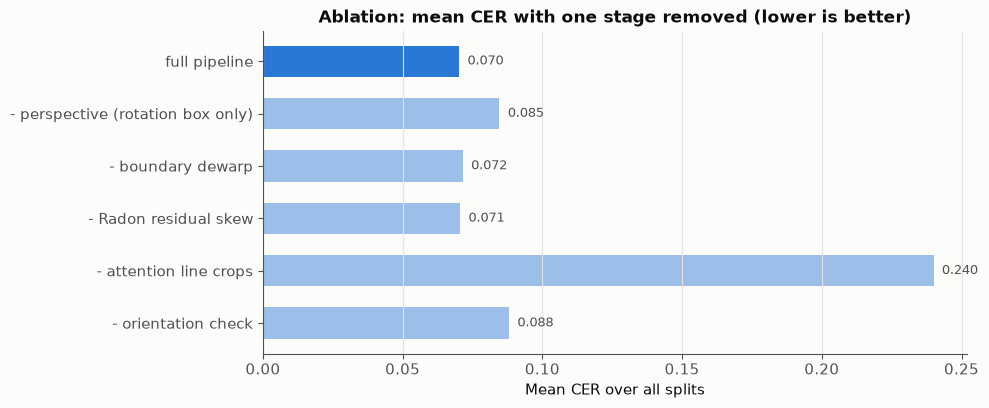

split,crumple,curvature,mixed,perspective,rotation,all
method,,,,,,
full pipeline,0.112,0.070,0.063,0.076,0.052,0.070
- perspective (rotation box only),0.130,0.072,0.093,0.095,0.047,0.085
- boundary dewarp,0.145,0.051,0.071,0.053,0.052,0.072
- Radon residual skew,0.112,0.071,0.063,0.076,0.052,0.071
- attention line crops,0.482,0.164,0.261,0.171,0.154,0.240
- orientation check,0.123,0.062,0.062,0.060,0.134,0.088


Stages whose removal raises CER: ['- perspective (rotation box only)', '- attention line crops', '- orientation check']
Stages with no measurable effect on these splits: ['- boundary dewarp', '- Radon residual skew']


In [43]:
ABLATIONS = {
    "full pipeline": PipelineOptions(),
    "- perspective (rotation box only)": PipelineOptions(perspective=False),
    "- boundary dewarp": PipelineOptions(dewarp=False),
    "- Radon residual skew": PipelineOptions(radon=False),
    "- attention line crops": PipelineOptions(line_crops=False),
    "- orientation check": PipelineOptions(orientation=False),
}
abl_path = config.RESULT_DIR / "ablation_results.csv"
if RUN_ABLATION and (RERUN_EVALUATION or not abl_path.exists()):
    abl_ann = ann   # all five splits, so every stage is tested on the distortion it targets
    readers = {k: (lambda o: (lambda img, eng: read_label(img, eng, o, detector=detector)))(o) for k, o in ABLATIONS.items()}
    abl = evaluate(abl_ann, config.SYNTH_DIR, readers=readers, desc="ablation:")
    abl.to_csv(abl_path, index=False)
elif abl_path.exists():
    abl = pd.read_csv(abl_path)
if RUN_ABLATION or abl_path.exists():
    ab = abl.groupby(["method", "split"]).cer.mean().unstack().reindex(list(ABLATIONS))
    ab["all"] = abl.groupby("method").cer.mean().reindex(list(ABLATIONS))
    fig, ax = plt.subplots(figsize=(10, 4.2))
    y = np.arange(len(ab))[::-1]
    ax.barh(y, ab["all"], color=[C["pipeline"]] + ["#9cbfe9"] * (len(ab) - 1), height=0.6)
    for yi, v in zip(y, ab["all"]):
        ax.text(v + 0.003, yi, f"{v:.3f}", va="center", fontsize=9, color=INK2)
    ax.set_yticks(y, ab.index); ax.set_xlabel("Mean CER over all splits"); ax.grid(axis="y", visible=False)
    ax.set_title("Ablation: mean CER with one stage removed (lower is better)")
    plt.tight_layout(); plt.savefig(config.FIG_DIR / "ablation.png", dpi=160, bbox_inches="tight"); plt.show()
    display(ab.round(3))
    worse = [k for k in ab.index[1:] if ab.loc[k, "all"] > ab.loc["full pipeline", "all"] + 0.005]
    flat = [k for k in ab.index[1:] if k not in worse]
    print("Stages whose removal raises CER:", worse)
    print("Stages with no measurable effect on these splits:", flat)

**Reading the ablation honestly:** a stage that shows no gain here isn't useless. It may only matter on the split it was
designed for (the perspective warp on the `perspective` split, the dewarp on strong `curvature`). Report the per-split
table, not just the overall bar. Each stage is also guarded (IoU check for the quad, fit-quality check for the dewarp,
confidence for the orientation), so when it can't help it switches itself off rather than hurting.

### 10.6 Second OCR engine: EasyOCR

Is the gain specific to Tesseract? Here EasyOCR (deep CRAFT detector + CRNN recogniser, which already tolerates some
rotation) gets the raw frame vs the output of our geometric layer, on a subset of the rotation split.
CPU-only and slow, so it uses 6 images per angle.

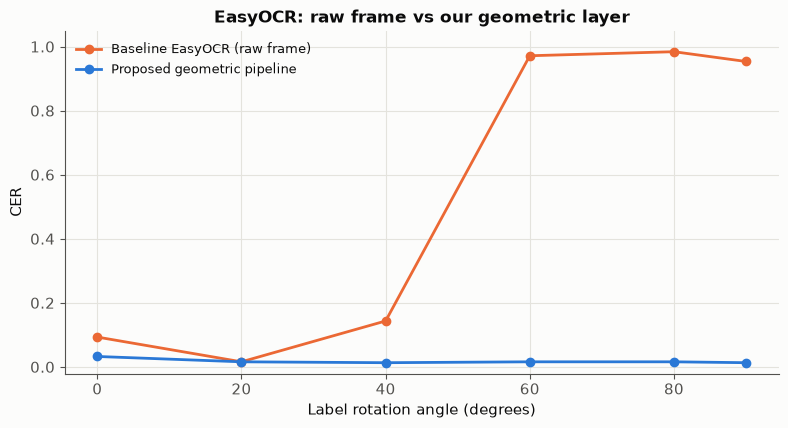

,CER,exact,latency_s
method,,,
baseline,0.528,0.306,8.348
pipeline,0.019,0.833,0.951


In [44]:
easy_path = config.RESULT_DIR / "easyocr_results.csv"
if RUN_EASYOCR:
    try:
        if RERUN_EVALUATION or not easy_path.exists():
            easy = get_engine("easyocr")
            sub = ann[(ann.split == "rotation") & (ann.level.isin([0, 20, 40, 60, 80, 90]))].groupby("level").head(6)
            er = evaluate(sub, config.SYNTH_DIR, readers={"baseline": read_baseline, "pipeline": lambda img, eng: read_label(img, eng, detector=detector)},
                          engine=easy, workers=1, desc="easyocr:")
            er.to_csv(easy_path, index=False)
        er = pd.read_csv(easy_path)
        fig, ax = plt.subplots(figsize=(8, 4.4))
        for m in ["baseline", "pipeline"]:
            g = er[er.method == m].groupby("level").cer.mean()
            ax.plot(g.index, g.values, marker="o", color=C[m], label=LABEL[m].replace("OCR", "EasyOCR"))
        ax.set_xlabel("Label rotation angle (degrees)"); ax.set_ylabel("CER"); ax.set_ylim(-0.02, 1.05)
        ax.set_title("EasyOCR: raw frame vs our geometric layer"); ax.legend(fontsize=9)
        plt.tight_layout(); plt.savefig(config.FIG_DIR / "easyocr_cer_vs_rotation.png", dpi=160, bbox_inches="tight"); plt.show()
        display(er.groupby("method").agg(CER=("cer", "mean"), exact=("exact", "mean"), latency_s=("latency_s", "median")).round(3))
    except Exception as e:
        print("EasyOCR not available, skipped:", e)

## 11. Real-world data: phone photos, phone camera stream, USB webcam (input layer, for real)

The synthetic dataset is a stand-in. Every function above takes an ordinary RGB image, so real data needs no code
changes. Four ways in:

**A. Folder of phone photos (simplest).** Put photos in `data/real/images/` (copy them over USB, Google Drive, or
WhatsApp-to-PC) and fill in `data/real/annotations.csv` with two columns, `filename,serial`
(for example `images/IMG_2041.jpg,SN-284517-XJ`). Optional extra columns like `angle` (for the CER-vs-angle plot)
or `expected_decision` are picked up automatically. Then run the cells below; they produce the same metrics and plots for real photos.

**B. Phone as a wireless webcam.** Install *IP Webcam* (Android) or *DroidCam* / *Iriun* (Android/iOS), connect the phone
to the same Wi-Fi as the laptop, and pass the stream URL (e.g. `http://192.168.1.23:8080/video`) as `SOURCE`.

**C. Phone browser upload page.** `start_phone_server()` serves a page at `http://<laptop-ip>:5000`. Open it on the phone,
tap the button, take a photo: the laptop runs the pipeline, lights the LED, returns the result and stage images, and
saves the photo (with the serial you type, if any) into `data/real/`, which builds your real dataset as you go.

**D. The actual rig (USB webcam).** `SOURCE = 0`. `live_scan()` detects when an object is placed and has stopped moving,
scans it once, and waits for it to be removed. This is the "software automatically detects the object" behaviour.

In [45]:
REAL_ANN = config.REAL_DIR / "annotations.csv"
if not REAL_ANN.exists():
    REAL_ANN.write_text("filename,serial,angle\n# images/IMG_0001.jpg,SN-284517-XJ,30\n")

def load_real_annotations():
    imgs = sorted(p for p in (config.REAL_DIR / "images").glob("*") if p.suffix.lower() in (".jpg", ".jpeg", ".png", ".heic", ".webp"))
    a = pd.read_csv(REAL_ANN, comment="#") if REAL_ANN.exists() else pd.DataFrame(columns=["filename", "serial"])
    known = set(a.filename) if len(a) else set()
    unlabeled = [f"images/{p.name}" for p in imgs if f"images/{p.name}" not in known]
    if unlabeled:   # photos without ground truth can still be processed (no CER), just not scored
        a = pd.concat([a, pd.DataFrame({"filename": unlabeled})], ignore_index=True)
    if "serial" in a and "expected_decision" not in a:
        a["expected_reason"] = [("OK" if db.items.loc[s, "status"] == "OK" else "FAULTY_LOT") if s in db.items.index
                                else "UNKNOWN_SERIAL" for s in a.serial.fillna("")]
        a["expected_decision"] = np.where(a.expected_reason == "OK", "PASS", "MISMATCH")
    if "angle" in a:
        a["split"], a["level"] = "rotation", a["angle"]
    return a

real_ann = load_real_annotations()
print(f"{len(real_ann)} real photos found in {config.REAL_DIR / 'images'}")
if len(real_ann):
    real_results = evaluate(real_ann, config.REAL_DIR, desc="real:")
    real_results.to_csv(config.RESULT_DIR / "real_results.csv", index=False)
    if "cer" in real_results:
        display(real_results.groupby("method").agg(CER=("cer", "mean"), exact=("exact", "mean")).reindex(list(READERS)))
    if "angle" in real_ann and real_ann.angle.notna().any() and "cer" in real_results:
        fig, ax = plt.subplots(figsize=(8, 4.4))
        for m in READERS:
            g = real_results[real_results.method == m].groupby("angle").cer.mean()
            ax.plot(g.index, g.values, marker="o", color=C[m], label=LABEL[m])
        ax.set_xlabel("Rotation angle (deg)"); ax.set_ylabel("CER"); ax.set_title("REAL photos: CER vs rotation angle"); ax.legend(fontsize=9)
        plt.tight_layout(); plt.savefig(config.FIG_DIR / "real_cer_vs_rotation.png", dpi=160); plt.show()
    first = real_ann.iloc[0]
    stage_panel(load_rgb(config.REAL_DIR / first.filename), first.get("serial") if isinstance(first.get("serial"), str) else None, name="real_0")
else:
    print("No real photos yet. Add them to data/real/images/ and their serials to data/real/annotations.csv, then re-run this cell.")

0 real photos found in E:\Wemby\label_verifier\data\real\images
No real photos yet. Add them to data/real/images/ and their serials to data/real/annotations.csv, then re-run this cell.


In [46]:
# ---- single photo from anywhere (e.g. a photo you just transferred from the phone) ----
PHOTO_PATH = None   # e.g. r"C:\Users\you\Downloads\IMG_2041.jpg"
if PHOTO_PATH:
    img = load_rgb(PHOTO_PATH)
    stage_panel(img, name=Path(PHOTO_PATH).stem)
    print(process_item(img, indicator=indicator, source="photo"))

In [47]:
def grab_frame(source=0, warmup=5):
    # source: 0/1 for a USB webcam, or a phone stream URL such as "http://192.168.1.23:8080/video"
    cap = cv2.VideoCapture(source)
    if isinstance(source, int):
        cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1920); cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 1080)
    for _ in range(warmup):
        ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"could not read from {source!r}")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def live_scan(source=0, max_scans=10, timeout_s=300, still_frames=6, fg_thresh=0.03, save_dir=config.INCOMING_DIR):
    # Auto-trigger loop for the real rig. Learns the empty scan area, waits until an object covers more than
    # fg_thresh of the frame and stays still for still_frames frames, scans once, waits for removal. Ctrl-C/stop to end.
    from IPython.display import clear_output
    cap = cv2.VideoCapture(source)
    ok, f0 = cap.read()
    if not ok:
        print("camera not available:", source); return
    small = lambda f: cv2.GaussianBlur(cv2.cvtColor(cv2.resize(f, (320, 240)), cv2.COLOR_BGR2GRAY), (5, 5), 0)
    empty = small(f0).astype(np.float32)
    prev, still, armed, scans, t_end = None, 0, True, 0, time.time() + timeout_s
    print("Learning empty scan area... place an item under the camera.")
    try:
        while scans < max_scans and time.time() < t_end:
            ok, frame = cap.read()
            if not ok:
                break
            s = small(frame)
            fg = (np.abs(s.astype(np.float32) - empty) > 25).mean()
            motion = 1.0 if prev is None else (cv2.absdiff(s, prev) > 15).mean()
            prev = s
            if fg < fg_thresh * 0.5:
                armed, still = True, 0
                cv2.accumulateWeighted(s.astype(np.float32), empty, 0.05)   # adapt to lighting drift
                continue
            still = still + 1 if motion < 0.004 else 0
            if armed and fg > fg_thresh and still >= still_frames:
                armed = False
                rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                cv2.imwrite(str(Path(save_dir) / f"scan_{time.strftime('%Y%m%d_%H%M%S')}.jpg"), frame)
                out = process_item(rgb, indicator=indicator, source=f"live:{source}")
                scans += 1
                clear_output(wait=True)
                plt.figure(figsize=(6, 4)); plt.imshow(rgb); plt.axis("off")
                plt.title(f"{out['decision']}  |  read {out['ocr_text']}  ->  {out['matched_serial']}"); plt.show()
                print(out)
    except KeyboardInterrupt:
        pass
    finally:
        cap.release()
    print(f"live scan finished ({scans} items)")


SOURCE = None    # set to 0 (USB webcam) or "http://<phone-ip>:8080/video" (IP Webcam app), then run
if SOURCE is not None:
    frame = grab_frame(SOURCE)
    stage_panel(frame, name="camera_test")
    # live_scan(SOURCE)      # <- the full auto-trigger station loop

In [48]:
PHONE_PAGE = '''<!doctype html><html><head><meta name="viewport" content="width=device-width,initial-scale=1">
<title>Label Scanner</title><style>
body{font-family:system-ui,sans-serif;margin:0;padding:16px;background:#fcfcfb;color:#0b0b0b;max-width:560px;margin:auto}
h1{font-size:20px} .btn{display:block;width:100%;padding:18px;font-size:18px;border:0;border-radius:10px;background:#2a78d6;color:#fff;margin:10px 0}
input[type=text]{width:100%;padding:12px;font-size:16px;box-sizing:border-box;border:1px solid #bbb;border-radius:8px}
.card{border-radius:10px;padding:14px;margin-top:14px;background:#fff;border:1px solid #ddd}
.PASS{border-left:10px solid #008300} .FAIL{border-left:10px solid #e34948} img{width:100%;border-radius:6px;margin-top:8px}
small{color:#52514e}</style></head><body>
<h1>Serial label verification</h1>
<form id=f><input type=file id=photo name=photo accept="image/*" capture="environment" hidden>
<button type=button class=btn onclick="photo.click()">📷 Take photo / choose image</button>
<input type=text name=truth placeholder="(optional) true serial, saves photo into the real dataset">
</form><div id=out></div>
<script>
photo.onchange=async()=>{const fd=new FormData(f);out.innerHTML='<p>Processing…</p>';
const r=await fetch('/scan',{method:'POST',body:fd});const j=await r.json();
const cls=j.decision==='PASS'?'PASS':'FAIL';const icon={PASS:'✅',MISMATCH:'❌',ERROR:'🔔'}[j.decision];
out.innerHTML=`<div class="card ${cls}"><b style="font-size:22px">${icon} ${j.decision}</b><br>
read <b>${j.ocr_text||'—'}</b> → matched <b>${j.matched_serial||'none'}</b><br><small>[${j.reason_code}] ${j.reason} · ${j.latency_ms} ms ·
${(j.record&&j.record.item)||''} ${(j.record&&j.record.location)||''}</small>
<img src="data:image/jpeg;base64,${j.detection}"><img src="data:image/jpeg;base64,${j.crop}"></div>`;photo.value='';};
</script></body></html>'''

def _b64(img, w=700):
    import base64
    if img is None:
        return ""
    if img.ndim == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    s = w / img.shape[1]
    img = cv2.resize(img, (w, int(img.shape[0] * s)))
    return base64.b64encode(cv2.imencode(".jpg", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))[1]).decode()

def start_phone_server(port=5000):
    from flask import Flask, request, jsonify
    import socket
    app = Flask("label_scanner")

    @app.get("/")
    def index():
        return PHONE_PAGE

    @app.post("/scan")
    def scan():
        data = np.frombuffer(request.files["photo"].read(), np.uint8)
        bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
        truth = (request.form.get("truth") or "").strip().upper()
        name = f"phone_{time.strftime('%Y%m%d_%H%M%S')}.jpg"
        if truth:  # labelled photo -> straight into the real dataset
            cv2.imwrite(str(config.REAL_DIR / "images" / name), bgr)
            with open(REAL_ANN, "a") as fh:
                fh.write(f"images/{name},{truth},\n")
        else:
            cv2.imwrite(str(config.INCOMING_DIR / name), bgr)
        r = read_label(rgb, engine, PipelineOptions(keep_stages=True))
        out = process_item(rgb, indicator=indicator, source="phone")
        crops = r.stages.get("crops") if r.stages.get("orientation", 0) == 0 else r.stages.get("crops_180")
        out.update(detection=_b64(r.stages.get("detection", r.stages.get("input"))),
                   crop=_b64(crops[0] if crops else r.stages.get("enhanced")))
        out["record"] = {k: (v if isinstance(v, (str, int, float)) else str(v)) for k, v in out["record"].items()}
        return jsonify(out)

    ip = socket.gethostbyname(socket.gethostname())
    threading.Thread(target=lambda: app.run(host="0.0.0.0", port=port, debug=False, use_reloader=False), daemon=True).start()
    print(f"Phone scanner running: open  http://{ip}:{port}  on your phone (same Wi-Fi). Allow Python through the firewall if asked.")

START_PHONE_SERVER = False
if START_PHONE_SERVER:
    start_phone_server()

## 12. Challenges, failure cases & limitations: measured (slide 13)

Each challenge on slide 13 is measured on the evaluation set, so the review can quote numbers instead of a list.

In [49]:
pipe = results[results.method == "pipeline"].copy()
base = results[results.method == "baseline"].set_index("filename").cer
def cond(name, mask):
    s = pipe[mask]
    return {"challenge (slide 13)": name, "images": len(s), "pipeline CER": s.cer.mean(), "pipeline exact": s.exact.mean(),
            "baseline CER": base.reindex(s.filename).mean()}
tbl = pd.DataFrame([
    cond("all frames", pipe.cer.notna()),
    cond("metallic / reflective plate", pipe.template == "metal"),
    cond("strong glare (≥ 0.5)", pipe.glare >= 0.5),
    cond("curved label (bend ≥ 0.15)", pipe.bend >= 0.15),
    cond("crumpled (≥ 9 px)", pipe.crumple >= 9),
    cond("steep camera angle (tilt ≥ 30°)", pipe.tilt >= 30),
    cond("defocus blur (σ ≥ 0.6 px)", pipe.blur >= 0.6),
    cond("uneven lighting (gradient ≥ 0.2)", pipe.light >= 0.2),
    cond("thermal OCR-A font (shipping)", pipe.template == "shipping"),
]).set_index("challenge (slide 13)")
display(tbl.style.format({"pipeline CER": "{:.3f}", "pipeline exact": "{:.0%}", "baseline CER": "{:.3f}"}))

,images,pipeline CER,pipeline exact,baseline CER
challenge (slide 13),,,,
all frames,496,0.070,71%,0.908
metallic / reflective plate,118,0.026,86%,0.887
strong glare (≥ 0.5),20,0.035,75%,0.960
curved label (bend ≥ 0.15),36,0.090,67%,0.788
crumpled (≥ 9 px),36,0.158,47%,0.954
steep camera angle (tilt ≥ 30°),50,0.087,76%,0.961
defocus blur (σ ≥ 0.6 px),177,0.074,72%,0.924
uneven lighting (gradient ≥ 0.2),124,0.067,73%,0.937
thermal OCR-A font (shipping),122,0.209,20%,0.885


### Failure cases

146 of 496 images have CER > 0; 35 are badly wrong (CER > 0.3)


split,crumple,curvature,mixed,perspective,rotation
images with errors,28,18,52,17,31


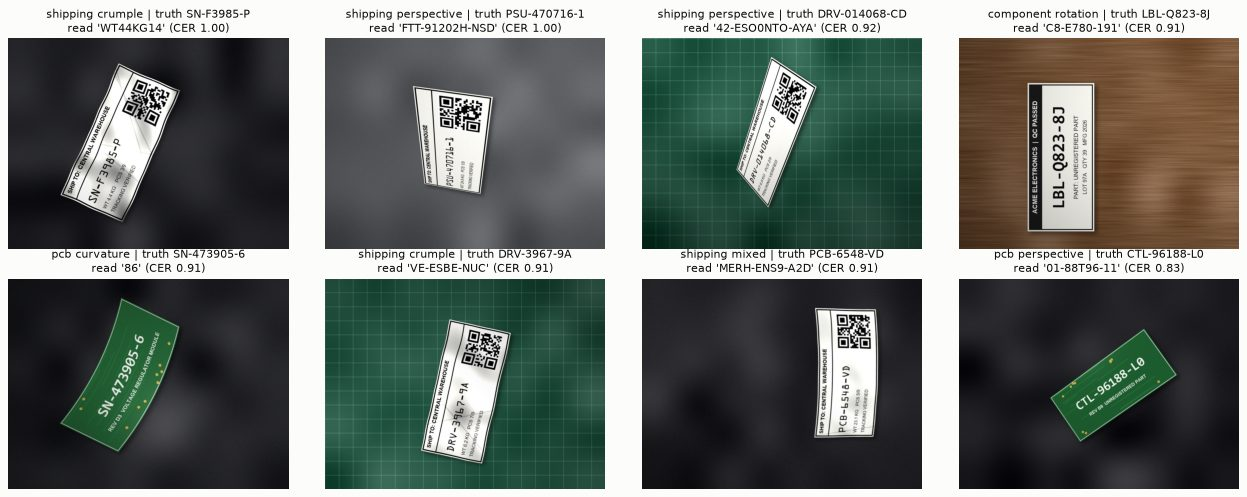

In [50]:
fails = results[(results.method == "pipeline") & (results.cer > 0)].sort_values("cer", ascending=False)
print(f"{len(fails)} of {(results.method == 'pipeline').sum()} images have CER > 0;",
      f"{(fails.cer > 0.3).sum()} are badly wrong (CER > 0.3)")
display(fails.groupby("split").size().rename("images with errors").to_frame().T)
show = fails.head(8)
imgs = [load_rgb(config.SYNTH_DIR / f) for f in show.filename]
show_images(imgs, [f"{r.template} {r.split} | truth {r.serial}\nread '{r.pred}' (CER {r.cer:.2f})" for r in show.itertuples()],
            cols=4, size=4.0, save="failure_cases.png")

**What to say about the failures:** most residual errors are (a) single-character confusions inside the OCR-A shipping font
(`6`↔`B`, `I`↔`1`), which the fuzzy inventory match absorbs, and (b) the most extreme crumpling, where creases cut through
the characters themselves. The database matcher refuses to guess when two serials are equally close, so these turn into a
red light and a re-scan rather than a false PASS.

**Prototype limitations (honest):**
* **Synthetic evaluation.** All numbers above are on generated frames. Real labels, lenses and lighting will differ.
  §11 runs the identical evaluation on real photos, and those numbers are the ones to quote in the final review.
* **Controlled set-up assumed.** A fixed overhead camera, and a mat that contrasts with the object (the generator excludes
  green-on-green and grey-on-grey on purpose).
* **Unseen label designs.** Four label families. A new layout (e.g. a serial printed vertically, or several serial-like
  fields) needs a format rule or a small amount of real training data.
* **Similar-looking characters** (`6/B`, `0/O`, `1/I`) remain the dominant OCR error (§10.2). The fuzzy inventory match
  absorbs one or two of them, but never at the cost of a false PASS.

## 13. Summary for Review 2 & future improvements

In [51]:
rot = results[results.split == "rotation"].pivot_table(index="level", columns="method", values="cer", aggfunc="mean")
yiou = det.yolo_iou
lines = [
    f"* **Dataset:** {len(ann)} synthetic test frames, 4 label families, rotation 0–90°, tilt to 50°, bending to 25 %, crumpling to 15 px. "
    f"YOLO trained on a separate set of {len(list((config.YOLO_DIR / 'images' / 'train').glob('*.jpg')))} frames.",
    f"* **Detection:** {detector.name} localises the label in {(yiou >= 0.5).mean():.1%} of test frames (mean IoU {yiou.mean():.2f}); "
    f"misses {int((yiou == 0).sum())}.",
    f"* **OCR (CER, lower is better):** baseline **{summary.loc['baseline', 'CER']:.3f}**, rotation-only **{summary.loc['rotation_only', 'CER']:.3f}**, "
    f"proposed pipeline **{summary.loc['pipeline', 'CER']:.3f}**. Exact serial reads: {summary.loc['baseline', 'exact_match']:.0%} → "
    f"{summary.loc['rotation_only', 'exact_match']:.0%} → **{summary.loc['pipeline', 'exact_match']:.0%}**.",
    f"* **Rotation sweep:** baseline CER {rot.loc[0, 'baseline']:.2f} at 0° rising to {rot['baseline'].iloc[1:].mean():.2f} averaged over 10–90°; "
    f"pipeline flat at {rot['pipeline'].mean():.2f} ± {rot['pipeline'].std():.2f}.",
    f"* **Decisions:** correct PASS/MISMATCH/ERROR for **{summary.loc['pipeline', 'decision_acc']:.0%}** of items (baseline {summary.loc['baseline', 'decision_acc']:.0%}); "
    f"**{fp['pipeline']} false PASS**; verification unit tests {(vt.result == '✅').sum()}/{len(vt)}.",
    f"* **System:** median end-to-end response {np.median(lat):.0f} ms (p95 {np.percentile(lat, 95):.0f} ms) on a laptop CPU; indicator byte correct for {np.mean(ok):.0%} of items.",
    f"* Figures: `{config.FIG_DIR.relative_to(config.ROOT)}`: " + ", ".join(sorted(p.name for p in config.FIG_DIR.glob('*.png'))),
]
display(Markdown("\n".join(lines)))

* **Dataset:** 496 synthetic test frames, 4 label families, rotation 0–90°, tilt to 50°, bending to 25 %, crumpling to 15 px. YOLO trained on a separate set of 400 frames.
* **Detection:** yolo localises the label in 100.0% of test frames (mean IoU 0.96); misses 0.
* **OCR (CER, lower is better):** baseline **0.908**, rotation-only **0.352**, proposed pipeline **0.070**. Exact serial reads: 3% → 43% → **71%**.
* **Rotation sweep:** baseline CER 0.42 at 0° rising to 0.94 averaged over 10–90°; pipeline flat at 0.05 ± 0.02.
* **Decisions:** correct PASS/MISMATCH/ERROR for **92%** of items (baseline 5%); **0 false PASS**; verification unit tests 10/10.
* **System:** median end-to-end response 1316 ms (p95 2040 ms) on a laptop CPU; indicator byte correct for 100% of items.
* Figures: `outputs\figures`: ablation.png, cer_vs_distortions.png, cer_vs_rotation.png, dataset_samples.png, decision_confusion.png, detection_testing.png, easyocr_cer_vs_rotation.png, failure_cases.png, ocr_error_types.png, per_template_and_latency.png, stages_crumple_metal.png, stages_curvature_pcb.png, stages_perspective_shipping.png, stages_rotation_component.png, system_latency.png, yolo_detections.png

### Future improvements (slide 14): status in this notebook

| Slide 14 item | Status |
|---|---|
| Optimise camera position, focus and lighting | Rig assumptions documented (§2); measure on the real rig with §11 |
| Expand and diversify the detection dataset | Generator makes unlimited labelled frames (§3); add real photos to `data/yolo` and retrain |
| Improve preprocessing for difficult label conditions | **Done:** geometric layer (§4), weaknesses quantified (§12: crumpling, OCR-A font) |
| Evaluate / tune OCR for the target character set | **Done:** serial alphabet, confusion map, format check (§5); EasyOCR comparison (§10.6) |
| Combine OCR with barcode / QR reading | **Done:** QR cross-check and tamper detection (§7) |
| Stronger format and consistency checks | **Done:** format regex, ambiguity guard, product-mapping check (§7, §10.3) |
| Larger inventory database and logging | SQLite `items` + `scans` tables (§2); swap in your real stock CSV |
| Real-time monitoring / dashboard | Phone web page shows each result live (§11 option C); the `scans` table is ready to chart |
| Dedicated edge-device deployment | YOLO11n + Tesseract run CPU-only at the latency in §10.4; next step: Raspberry Pi 5 / Jetson test |

**Next steps toward the final review:** (1) photograph 10 printed labels at 0/15/30/45/60/75/90° on the real rig, then
re-run §11 for real CER-vs-angle; (2) add ~50 real frames to the YOLO set and retrain; (3) flash
`hardware/indicator/indicator.ino`, plug in the board, and re-run §8.